# Library

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import randint, uniform
import shap

/mnt/extended-home/ismaprasetiyadi/skripsi/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
data = pd.read_csv('/mnt/extended-home/ismaprasetiyadi/skripsi/data/final_data_ready_modelling.csv')
data.head(3)

,Harga_Asli,kecamatan,bedroom,bathrooms,jumlah_guest_toilet,lantai,area_digunakan,luas_tanah,latitude,longitude,...,Rumah jaga,Spa dan Sauna,Taman,Taman atap,Taman bermain anak,Tidak Ada,akses_transportasi,akses_pendidikan,akses_komersial,fasilitas_premium
0,385000000,Wonoayu,2,1,1,1,34,10,-7.437160,112.622220,...,1,0,1,0,0,0,5.362372,5.405134,8.244602,0
1,540000000,Sedati,2,1,1,1,32,32,-7.395451,112.769745,...,1,0,1,0,0,0,2.463128,1.168335,5.299212,0
2,1960000000,Candi,4,3,3,3,72,32,-7.458483,112.700560,...,1,0,1,0,0,0,1.945620,0.674588,1.426830,0


# Split train test (8:2)

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Pastikan kolom kecamatan ada
assert "kecamatan" in data.columns, "Kolom 'kecamatan' tidak ditemukan"

train_list = []
test_list = []

# Split per kecamatan
for kec, df_kec in data.groupby("kecamatan"):
    
    # Jika data sangat sedikit, amankan minimal 1 data di test
    if len(df_kec) < 5:
        train_kec = df_kec
        test_kec = df_kec.iloc[0:0]  # kosong
    else:
        train_kec, test_kec = train_test_split(
            df_kec,
            test_size=0.2,
            random_state=42
        )
    
    train_list.append(train_kec)
    test_list.append(test_kec)

# Gabungkan kembali
df_train = pd.concat(train_list).sample(frac=1, random_state=42).reset_index(drop=True)
df_test  = pd.concat(test_list).sample(frac=1, random_state=42).reset_index(drop=True)

print("Jumlah data TRAIN:", df_train.shape[0])
print("Jumlah data TEST :", df_test.shape[0])


Jumlah data TRAIN: 978
Jumlah data TEST : 253


In [4]:
check = (
    data.groupby("kecamatan").size()
    .to_frame("total")
    .join(df_train.groupby("kecamatan").size().to_frame("train"))
    .join(df_test.groupby("kecamatan").size().to_frame("test"))
)

check["train_ratio"] = check["train"] / check["total"]
check["test_ratio"]  = check["test"] / check["total"]

check.sort_values("total")


,total,train,test,train_ratio,test_ratio
kecamatan,,,,,
Tarik,5,4,1,0.800000,0.200000
Porong,5,4,1,0.800000,0.200000
Jabon,12,9,3,0.750000,0.250000
Tanggulangin,16,12,4,0.750000,0.250000
Balongbendo,17,13,4,0.764706,0.235294
Prambon,33,26,7,0.787879,0.212121
Wonoayu,39,31,8,0.794872,0.205128
Krembung,44,35,9,0.795455,0.204545
Tulangan,45,36,9,0.800000,0.200000


# Sample Weight Imbalance Kecamatan

In [5]:
import numpy as np

kec_count = df_train["kecamatan"].value_counts()

kec_weight = 1 / np.sqrt(kec_count)

df_train["sample_weight"] = df_train["kecamatan"].map(kec_weight)
df_train["sample_weight"] = df_train["sample_weight"] / df_train["sample_weight"].mean()

In [6]:
df_train.groupby("kecamatan")["sample_weight"].agg(["count", "mean"]).sort_values("mean", ascending=False)


,count,mean
kecamatan,,
Porong,4,4.081831
Tarik,4,4.081831
Jabon,9,2.721221
Tanggulangin,12,2.356647
Balongbendo,13,2.264193
Prambon,26,1.601026
Wonoayu,31,1.466237
Krembung,35,1.379911
Krian,36,1.360610


In [7]:
X_train = df_train.drop(columns=["Harga_Asli"])
y_train = df_train["Harga_Asli"]

# Ambil sample weight
sample_weight_train = df_train["sample_weight"].values
sample_weight_train

array([0.85578441, 0.8511207 , 0.85578441, 0.58611684, 0.93033574,
       0.74523706, 1.36061049, 0.8511207 , 0.8511207 , 0.85578441,
       0.58611684, 0.93033574, 0.74523706, 0.85578441, 1.36061049,
       1.01257777, 0.93033574, 0.8511207 , 0.58611684, 1.36061049,
       0.93033574, 1.04524993, 0.58611684, 1.36061049, 0.74523706,
       0.8511207 , 0.58611684, 0.58611684, 1.01257777, 1.36061049,
       0.93033574, 0.93033574, 0.74523706, 2.72122099, 0.74523706,
       0.74523706, 1.46623715, 0.58611684, 0.58611684, 0.74523706,
       1.36061049, 1.36061049, 1.3799109 , 0.85578441, 0.96209691,
       0.8511207 , 1.36061049, 1.04524993, 0.8511207 , 1.60102603,
       0.58611684, 0.8511207 , 0.93033574, 0.58611684, 1.36061049,
       1.36061049, 0.58611684, 0.93033574, 1.01257777, 1.36061049,
       1.3799109 , 0.85578441, 1.01257777, 0.74523706, 0.8511207 ,
       0.74523706, 1.01257777, 0.93033574, 1.04524993, 1.46623715,
       1.60102603, 4.08183148, 1.36061049, 0.8511207 , 0.74523

# Modelling

## XGBoost

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 978 entries, 0 to 977
Data columns (total 76 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Harga_Asli                         978 non-null    int64  
 1   kecamatan                          978 non-null    object 
 2   bedroom                            978 non-null    int64  
 3   bathrooms                          978 non-null    int64  
 4   jumlah_guest_toilet                978 non-null    int64  
 5   lantai                             978 non-null    int64  
 6   area_digunakan                     978 non-null    int64  
 7   luas_tanah                         978 non-null    int64  
 8   latitude                           978 non-null    float64
 9   longitude                          978 non-null    float64
 10  dist_SD                            978 non-null    float64
 11  dist_Universitas                   978 non-null    float64

In [11]:
# TARGET & FEATURE
y_train_XB = df_train["Harga_Asli"]
X_train_XB = df_train.drop(columns=["Harga_Asli","kecamatan","latitude","longitude","sample_weight"])

y_test_XB = df_test["Harga_Asli"]
X_test_XB = df_test.drop(columns=["Harga_Asli","kecamatan","latitude","longitude"])

# GROUP UNTUK SPATIAL CV
groups = df_train["kecamatan"]

In [12]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [13]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    eval_metric="rmse",
    max_bin=512,
    n_jobs=1,
    verbosity=0
)

param_dist = {
    "n_estimators": randint(300, 800),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2)
}


In [14]:
cv = GroupKFold(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=1,
    error_score="raise"
)

random_search.fit(
    X_train_XB,
    y_train_XB,
    groups=groups,
    sample_weight=sample_weight_train
)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=402, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7836995567863468; total time=   1.9s
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=402, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7836995567863468; total time=   1.5s
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=402, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7836995567863468; total time=   1.5s
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_e

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....x7fda1ab98e50>, 'gamma': <scipy.stats....x7fda1ae3a310>, 'learning_rate': <scipy.stats....x7fda1d96c090>, 'max_depth': <scipy.stats....x7fda1abae6d0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :r

In [15]:
best_model = random_search.best_estimator_

print("Best Params:")
print(random_search.best_params_)

Best Params:
{'colsample_bytree': 0.6831766651472755, 'gamma': 2.8385016390999573, 'learning_rate': 0.016262658491111717, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 501, 'reg_alpha': 0.8948273504276488, 'reg_lambda': 1.6957999576221703, 'subsample': 0.9687496940092467}


In [16]:
results = []

for train_idx, test_idx in cv.split(X_train_XB, y_train_XB, groups):
    X_train_fold, X_test = X_train_XB.iloc[train_idx], X_train_XB.iloc[test_idx]
    y_train_fold, y_test = y_train_XB.iloc[train_idx], y_train_XB.iloc[test_idx]
    w_train_fold = sample_weight_train[train_idx]

    model = best_model
    model.fit(X_train_fold, y_train_fold, sample_weight=w_train_fold)

    y_pred = model.predict(X_test)

    df_eval = df_train.iloc[test_idx].copy()
    df_eval["y_true"] = y_test.values
    df_eval["y_pred"] = y_pred

    for kec, g in df_eval.groupby("kecamatan"):
        rmse = np.sqrt(mean_squared_error(g["y_true"], g["y_pred"]))
        mae = mean_absolute_error(g["y_true"], g["y_pred"])
        results.append([kec, len(g), rmse, mae])

eval_df = pd.DataFrame(
    results,
    columns=["kecamatan", "n_samples", "RMSE", "MAE"]
)


In [17]:
median_size = eval_df["n_samples"].median()

eval_df["group"] = np.where(
    eval_df["n_samples"] >= median_size,
    "besar",
    "kecil"
)

summary_group = eval_df.groupby("group")[["RMSE", "MAE"]].mean()
print(summary_group)


               RMSE          MAE
group                           
besar  8.104694e+08  387626720.0
kecil  1.731440e+09  842804312.0


In [22]:
importance = pd.DataFrame({
    "feature": X_train_XB.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(20))

                   feature  importance
26         Halaman terbuka    0.103837
61              Rumah jaga    0.066105
11     dist_Entry_Exit_Tol    0.058610
0                  bedroom    0.058041
4           area_digunakan    0.051828
13            has_exit_tol    0.048902
15                     Air    0.043464
5               luas_tanah    0.037269
55                Keamanan    0.034989
1                bathrooms    0.034477
37  Pendingin ruangan (AC)    0.033524
6                  dist_SD    0.032126
23                  Garasi    0.027740
12              road_score    0.025074
66               Tidak Ada    0.021965
28       Jaringan internet    0.021708
17                  Balkon    0.021672
39            Ruang kantor    0.020537
3                   lantai    0.020207
25                 Halaman    0.018108


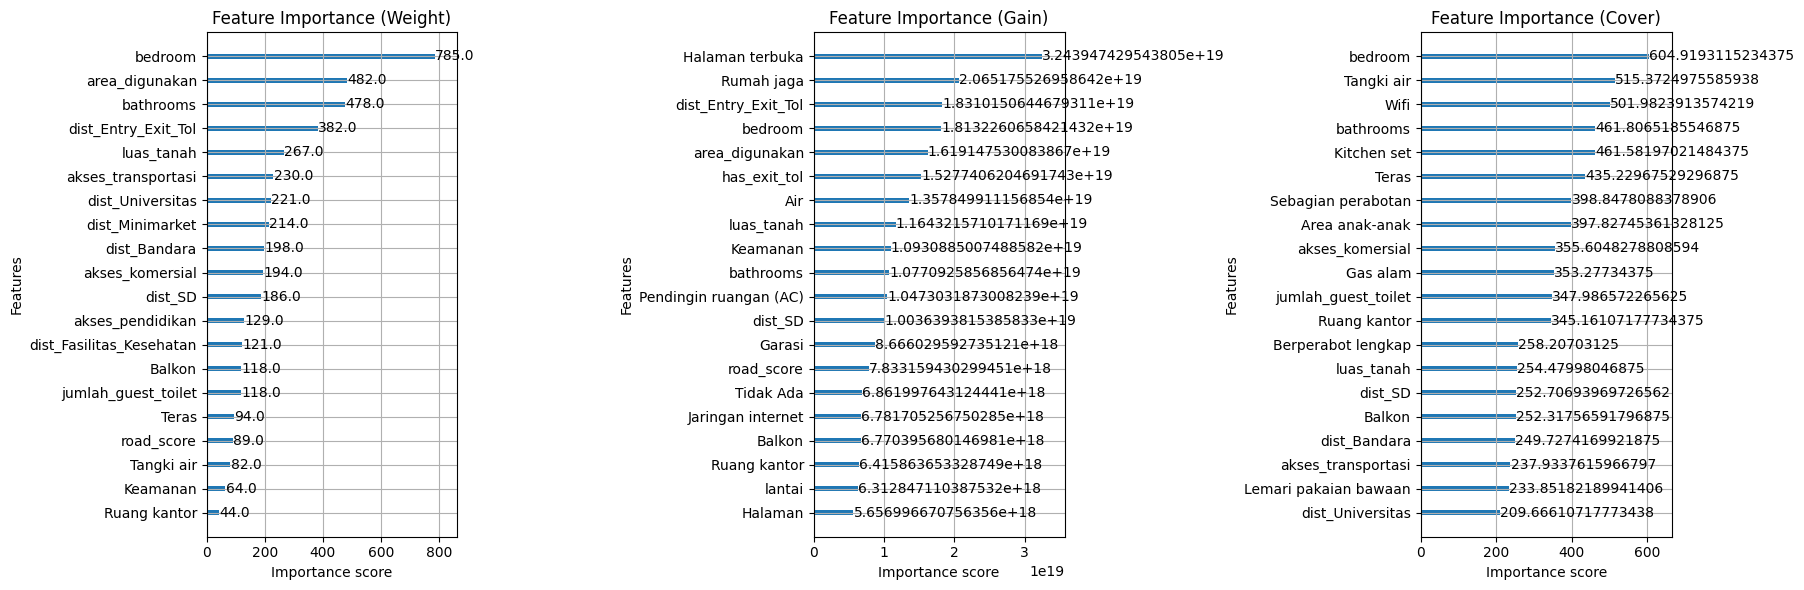


Top 20 Features (Average of Weight, Gain, Cover):
                   feature  importance_weight  importance_gain  \
15         Halaman terbuka               10.0     3.243947e+19   
29              Rumah jaga               30.0     2.065176e+19   
46     dist_Entry_Exit_Tol              382.0     1.831015e+19   
44                 bedroom              785.0     1.813226e+19   
42          area_digunakan              482.0     1.619148e+19   
51            has_exit_tol               16.0     1.527741e+19   
1                      Air               21.0     1.357850e+19   
54              luas_tanah              267.0     1.164322e+19   
19                Keamanan               64.0     1.093089e+19   
43               bathrooms              478.0     1.077093e+19   
26  Pendingin ruangan (AC)               39.0     1.047303e+19   
49                 dist_SD              186.0     1.003639e+19   
11                  Garasi               20.0     8.666030e+18   
55              road_scor

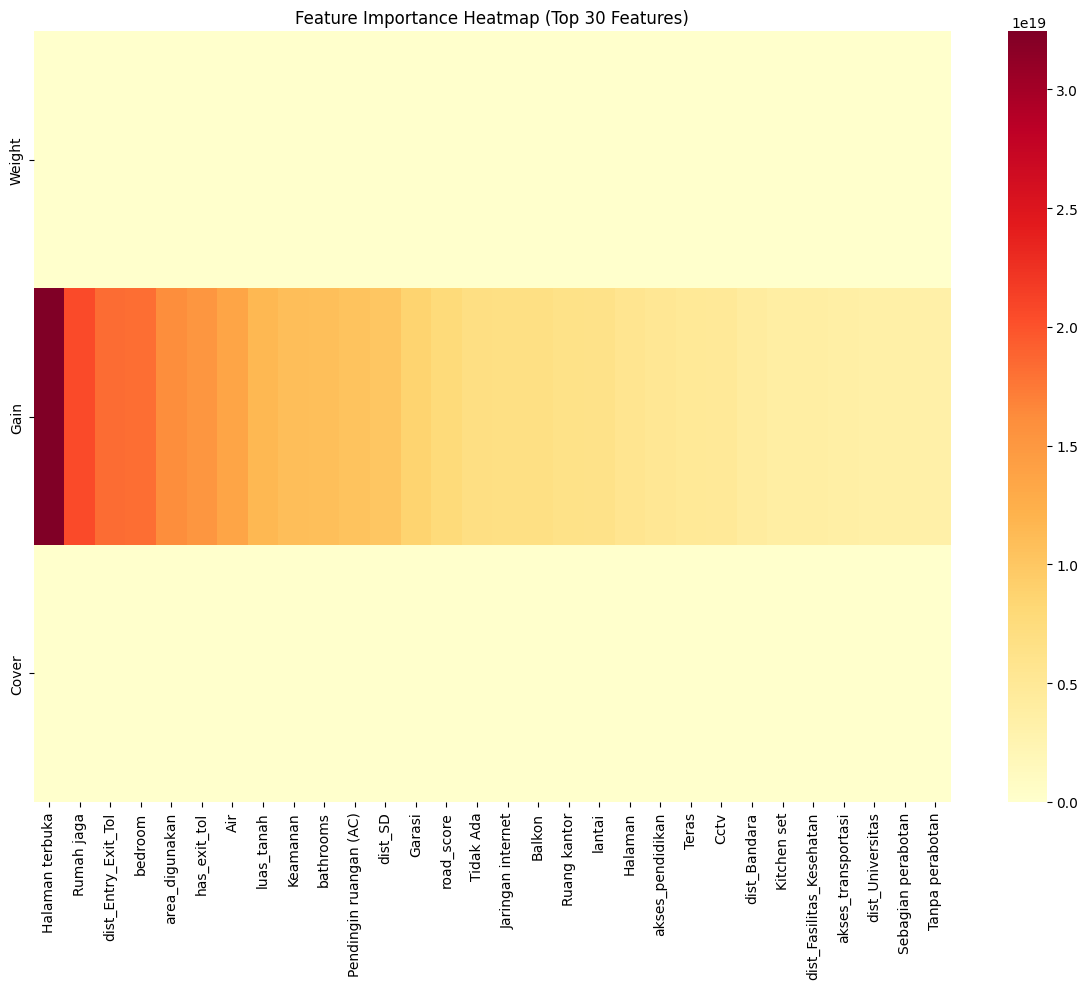

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import plot_importance

# Method 1: XGBoost plot_importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Weight importance
plot_importance(best_model, importance_type='weight', max_num_features=20, ax=axes[0])
axes[0].set_title('Feature Importance (Weight)')

# Gain importance
plot_importance(best_model, importance_type='gain', max_num_features=20, ax=axes[1])
axes[1].set_title('Feature Importance (Gain)')

# Cover importance
plot_importance(best_model, importance_type='cover', max_num_features=20, ax=axes[2])
axes[2].set_title('Feature Importance (Cover)')

plt.tight_layout()
plt.show()

# Method 2: Custom DataFrame Analysis
importance_types = ['weight', 'gain', 'cover']
importance_df = pd.DataFrame()

for imp_type in importance_types:
    booster = best_model.get_booster()
    importance_dict = booster.get_score(importance_type=imp_type)
    temp_df = pd.DataFrame({
        'feature': list(importance_dict.keys()),
        f'importance_{imp_type}': list(importance_dict.values())
    })
    if importance_df.empty:
        importance_df = temp_df
    else:
        importance_df = importance_df.merge(temp_df, on='feature', how='outer')

importance_df = importance_df.fillna(0)
importance_df['avg_importance'] = importance_df[[f'importance_{t}' for t in importance_types]].mean(axis=1)
importance_df = importance_df.sort_values('avg_importance', ascending=False)

print("\nTop 20 Features (Average of Weight, Gain, Cover):")
print(importance_df.head(20))

# Heatmap
plt.figure(figsize=(12, 10))
top_features = importance_df.head(30)
heatmap_data = top_features[[f'importance_{t}' for t in importance_types]].T
sns.heatmap(heatmap_data, 
            xticklabels=top_features['feature'],
            yticklabels=['Weight', 'Gain', 'Cover'],
            cmap='YlOrRd',
            annot=False,
            fmt='.2f')
plt.title('Feature Importance Heatmap (Top 30 Features)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### SHAP

In [24]:
# SHAP Analysis untuk XGBoost
# Solusi FINAL: Menggunakan numpy array dan xgboost.Booster untuk menghindari semua error

import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SHAP ANALYSIS - XGBOOST MODEL")
print("="*80)

# Step 1: Ambil sample data untuk efisiensi komputasi
print("\n[1/6] Preparing data for SHAP analysis...")
n_samples = min(1000, len(X_train_XB))
sample_indices = X_train_XB.sample(n_samples, random_state=42).index
X_shap_sample = X_train_XB.loc[sample_indices].copy()
y_shap_sample = y_train_XB.loc[sample_indices].copy()

# Simpan nama kolom untuk nanti
feature_names = X_shap_sample.columns.tolist()

# Convert ke numpy array (menghindari masalah feature_names_in_)
X_shap_np = X_shap_sample.values
y_shap_np = y_shap_sample.values

print(f"   Sample size: {X_shap_np.shape}")
print(f"   Features: {len(feature_names)}")

# Step 2: Buat model baru dengan sklearn-compatible approach
print("\n[2/6] Creating fresh XGBoost model for SHAP...")
best_params = random_search.best_params_.copy()

# Buat model tanpa feature names (pure numpy)
import xgboost as xgb

# Gunakan DMatrix untuk kontrol penuh
dtrain = xgb.DMatrix(X_shap_np, label=y_shap_np, feature_names=feature_names)

# Parameter untuk training
xgb_params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'max_depth': best_params.get('max_depth', 4),
    'learning_rate': best_params.get('learning_rate', 0.01),
    'subsample': best_params.get('subsample', 0.7),
    'colsample_bytree': best_params.get('colsample_bytree', 0.7),
    'min_child_weight': best_params.get('min_child_weight', 2),
    'gamma': best_params.get('gamma', 3),
    'reg_alpha': best_params.get('reg_alpha', 0.4),
    'reg_lambda': best_params.get('reg_lambda', 2.5),
    'seed': 42,
    'verbosity': 0
}

n_estimators = best_params.get('n_estimators', 500)
print(f"   Params: max_depth={xgb_params['max_depth']}, n_estimators={n_estimators}")

# Step 3: Train model
print("\n[3/6] Training XGBoost model...")
booster = xgb.train(xgb_params, dtrain, num_boost_round=n_estimators)
print("   ✓ Model trained successfully")

# Step 4: Verify model performance
print("\n[4/6] Verifying model performance...")
train_pred = booster.predict(dtrain)
train_rmse = np.sqrt(mean_squared_error(y_shap_np, train_pred))
train_mae = mean_absolute_error(y_shap_np, train_pred)
print(f"   RMSE: Rp {train_rmse:,.0f}")
print(f"   MAE: Rp {train_mae:,.0f}")

# Step 5: Create SHAP explainer dengan Booster
print("\n[5/6] Creating SHAP TreeExplainer...")
shap_success = False
shap_values = None
explainer = None
expected_value = None

try:
    # Method: Gunakan TreeExplainer dengan booster langsung
    explainer = shap.TreeExplainer(booster)
    expected_value = explainer.expected_value
    print("   ✓ TreeExplainer created successfully")
    shap_success = True
except Exception as e:
    print(f"   ✗ TreeExplainer failed: {str(e)[:100]}")
    
    # Fallback: Gunakan predict function untuk KernelExplainer
    try:
        print("   Trying KernelExplainer with predict function...")
        
        def predict_fn(X):
            dmatrix = xgb.DMatrix(X, feature_names=feature_names)
            return booster.predict(dmatrix)
        
        background = X_shap_np[np.random.choice(len(X_shap_np), min(100, len(X_shap_np)), replace=False)]
        explainer = shap.KernelExplainer(predict_fn, background)
        expected_value = explainer.expected_value
        print("   ✓ KernelExplainer created successfully")
        shap_success = True
    except Exception as e2:
        print(f"   ✗ KernelExplainer failed: {str(e2)[:100]}")

# Step 6: Calculate SHAP values
if shap_success and explainer is not None:
    print("\n[6/6] Calculating SHAP values...")
    try:
        if isinstance(explainer, shap.TreeExplainer):
            shap_values = explainer.shap_values(dtrain)
        else:
            # KernelExplainer
            shap_values = explainer.shap_values(X_shap_np, nsamples=100, silent=True)
        
        print(f"   ✓ SHAP values calculated!")
        print(f"   Shape: {shap_values.shape}")
        print(f"   Base value: Rp {float(expected_value):,.0f}")
        print("\n" + "="*80)
        print("✓ SHAP ANALYSIS COMPLETED SUCCESSFULLY!")
        print("="*80)
    except Exception as e:
        print(f"\n   ✗ Failed to calculate SHAP values: {e}")
        shap_success = False
        shap_values = None
else:
    print("\n" + "="*80)
    print("✗ SHAP ANALYSIS FAILED - Using Permutation Importance instead")
    print("="*80)
    shap_values = None

SHAP ANALYSIS - XGBOOST MODEL

[1/6] Preparing data for SHAP analysis...
   Sample size: (978, 71)
   Features: 71

[2/6] Creating fresh XGBoost model for SHAP...
   Params: max_depth=4, n_estimators=501

[3/6] Training XGBoost model...
   ✓ Model trained successfully

[4/6] Verifying model performance...
   RMSE: Rp 493,164,144
   MAE: Rp 232,198,368

[5/6] Creating SHAP TreeExplainer...
   ✗ TreeExplainer failed: could not convert string to float: '[9.872003E8]'
   Trying KernelExplainer with predict function...
   ✓ KernelExplainer created successfully

[6/6] Calculating SHAP values...
   ✓ SHAP values calculated!
   Shape: (978, 71)
   Base value: Rp 1,008,252,146

✓ SHAP ANALYSIS COMPLETED SUCCESSFULLY!


In [25]:
# Summary Statistics SHAP Values
if shap_values is not None:
    print("="*80)
    print("SHAP ANALYSIS SUMMARY")
    print("="*80)

    shap_summary = pd.DataFrame({
        'Feature': feature_names,
        'Mean_|SHAP|': np.abs(shap_values).mean(axis=0),
        'Std_SHAP': np.abs(shap_values).std(axis=0),
        'Max_|SHAP|': np.abs(shap_values).max(axis=0),
        'Mean_SHAP': shap_values.mean(axis=0)
    }).sort_values('Mean_|SHAP|', ascending=False)

    print("\nTop 20 Features by Mean Absolute SHAP Value:")
    print(shap_summary.head(20).to_string(index=False))

    print("\n" + "="*80)
    print(f"Model Base Value (Expected): Rp {float(expected_value):,.0f}")
    print(f"Mean Prediction: Rp {train_pred.mean():,.0f}")
    print(f"Actual Mean Price: Rp {y_shap_np.mean():,.0f}")
    print("="*80)
else:
    print("⚠ SHAP values not available. Skipping summary.")

SHAP ANALYSIS SUMMARY

Top 20 Features by Mean Absolute SHAP Value:
                 Feature  Mean_|SHAP|     Std_SHAP   Max_|SHAP|     Mean_SHAP
               bathrooms 2.078699e+08 3.055118e+08 4.425020e+09 -2.437115e+07
                 bedroom 1.892178e+08 5.874767e+08 1.174587e+10  4.050185e+07
          area_digunakan 4.491577e+07 9.523197e+07 1.597551e+09 -6.838514e+06
         akses_komersial 4.018119e+07 5.220250e+07 7.331954e+08 -4.138349e+06
                  Balkon 3.570960e+07 9.180762e+07 1.901273e+09  2.345866e+06
     dist_Entry_Exit_Tol 3.077273e+07 1.308138e+08 2.622092e+09  9.502061e+06
              Tangki air 2.932144e+07 6.679011e+07 1.105041e+09  8.513201e+06
              road_score 2.368833e+07 1.115407e+08 2.289063e+09 -3.960243e+06
     jumlah_guest_toilet 2.215851e+07 4.560301e+07 4.901611e+08 -6.372965e+06
        dist_Universitas 2.135877e+07 6.942058e+07 1.260264e+09 -4.698921e+05
            dist_Bandara 1.840768e+07 4.319378e+07 5.496420e+08 -6.051362e

In [26]:
# Export SHAP values untuk analisis lebih lanjut
if shap_values is not None:
    shap_df = pd.DataFrame(
        shap_values,
        columns=[f'shap_{col}' for col in feature_names]
    )

    # Gabung dengan data asli
    shap_analysis_df = pd.concat([
        X_shap_sample.reset_index(drop=True),
        shap_df.reset_index(drop=True),
        pd.Series(y_shap_np, name='actual_price')
    ], axis=1)

    # Tambahkan prediksi
    shap_analysis_df['predicted_price'] = train_pred
    shap_analysis_df['prediction_error'] = shap_analysis_df['actual_price'] - shap_analysis_df['predicted_price']

    print("SHAP Analysis DataFrame:")
    print(shap_analysis_df.head())
    print(f"\nShape: {shap_analysis_df.shape}")
else:
    print("⚠ SHAP values not available. Skipping export.")

SHAP Analysis DataFrame:
   bedroom  bathrooms  jumlah_guest_toilet  lantai  area_digunakan  \
0        2          1                    1       1              36   
1        3          2                    0       2              90   
2        3          2                    2       1              50   
3        2          1                    0       1             150   
4        2          1                    1       1             100   

   luas_tanah   dist_SD  dist_Universitas  dist_Fasilitas_Kesehatan  \
0          72  3.909136          7.258131                  5.708731   
1          90  2.631206          6.911361                  5.760949   
2         112  1.342664          4.772823                  1.479492   
3         135  2.579776          4.922090                  2.978413   
4         128  1.045183          3.275766                  6.202500   

   dist_Minimarket  ...  shap_Taman atap  shap_Taman bermain anak  \
0         3.554818  ...    -6.520389e+06                  

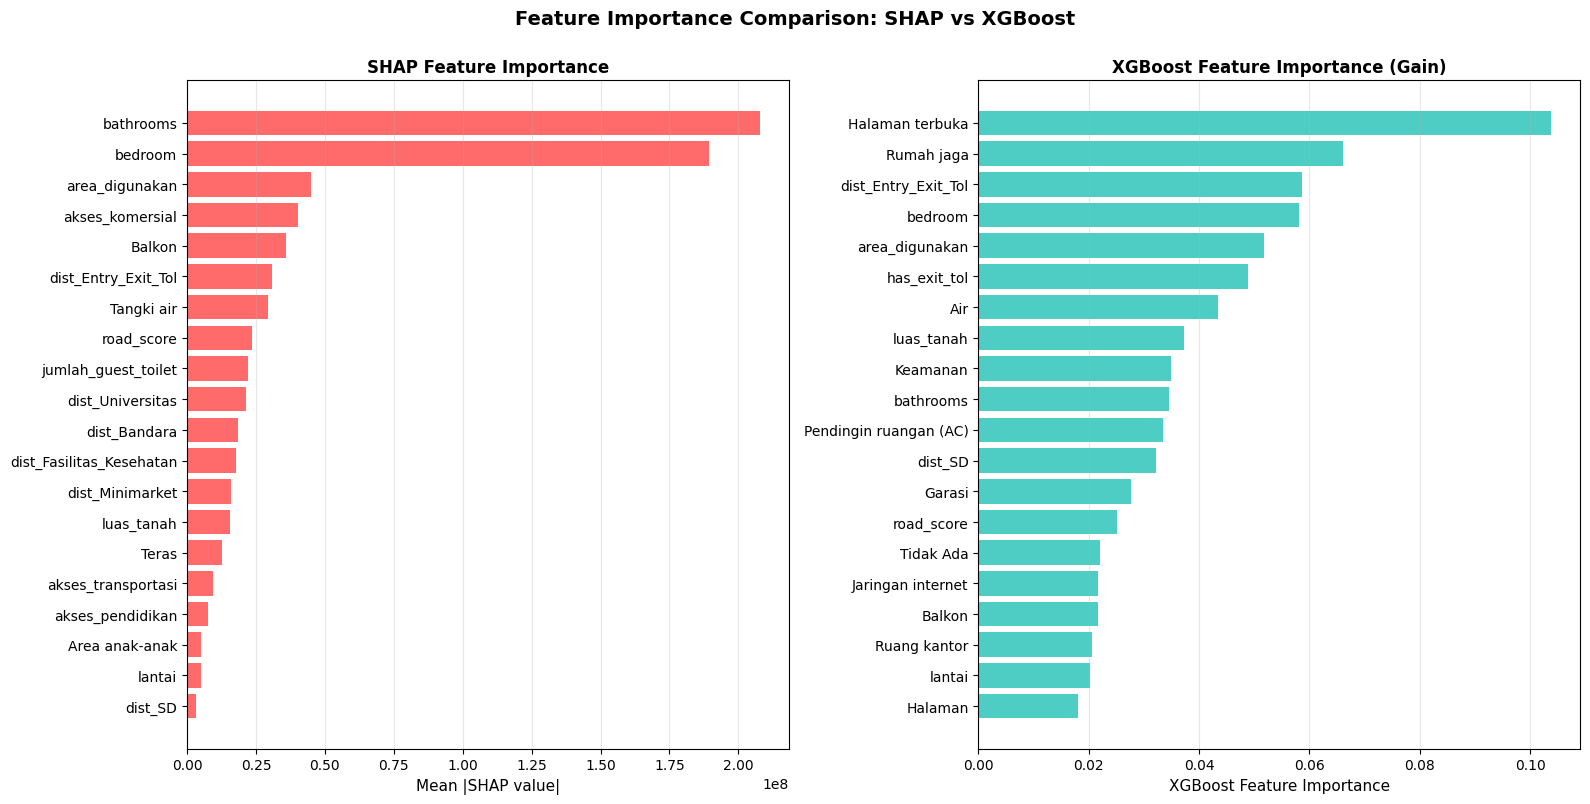

In [28]:
# SHAP Feature Importance Comparison dengan XGBoost Feature Importance
if shap_values is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # SHAP Importance
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('shap_importance', ascending=True).tail(20)

    axes[0].barh(range(len(shap_importance)), shap_importance['shap_importance'], color='#FF6B6B')
    axes[0].set_yticks(range(len(shap_importance)))
    axes[0].set_yticklabels(shap_importance['feature'])
    axes[0].set_xlabel('Mean |SHAP value|', fontsize=11)
    axes[0].set_title('SHAP Feature Importance', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # XGBoost Importance (Gain)
    xgb_importance = pd.DataFrame({
        'feature': X_train_XB.columns,
        'xgb_importance': best_model.feature_importances_
    }).sort_values('xgb_importance', ascending=True).tail(20)

    axes[1].barh(range(len(xgb_importance)), xgb_importance['xgb_importance'], color='#4ECDC4')
    axes[1].set_yticks(range(len(xgb_importance)))
    axes[1].set_yticklabels(xgb_importance['feature'])
    axes[1].set_xlabel('XGBoost Feature Importance', fontsize=11)
    axes[1].set_title('XGBoost Feature Importance (Gain)', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    plt.suptitle('Feature Importance Comparison: SHAP vs XGBoost', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping comparison plot.")

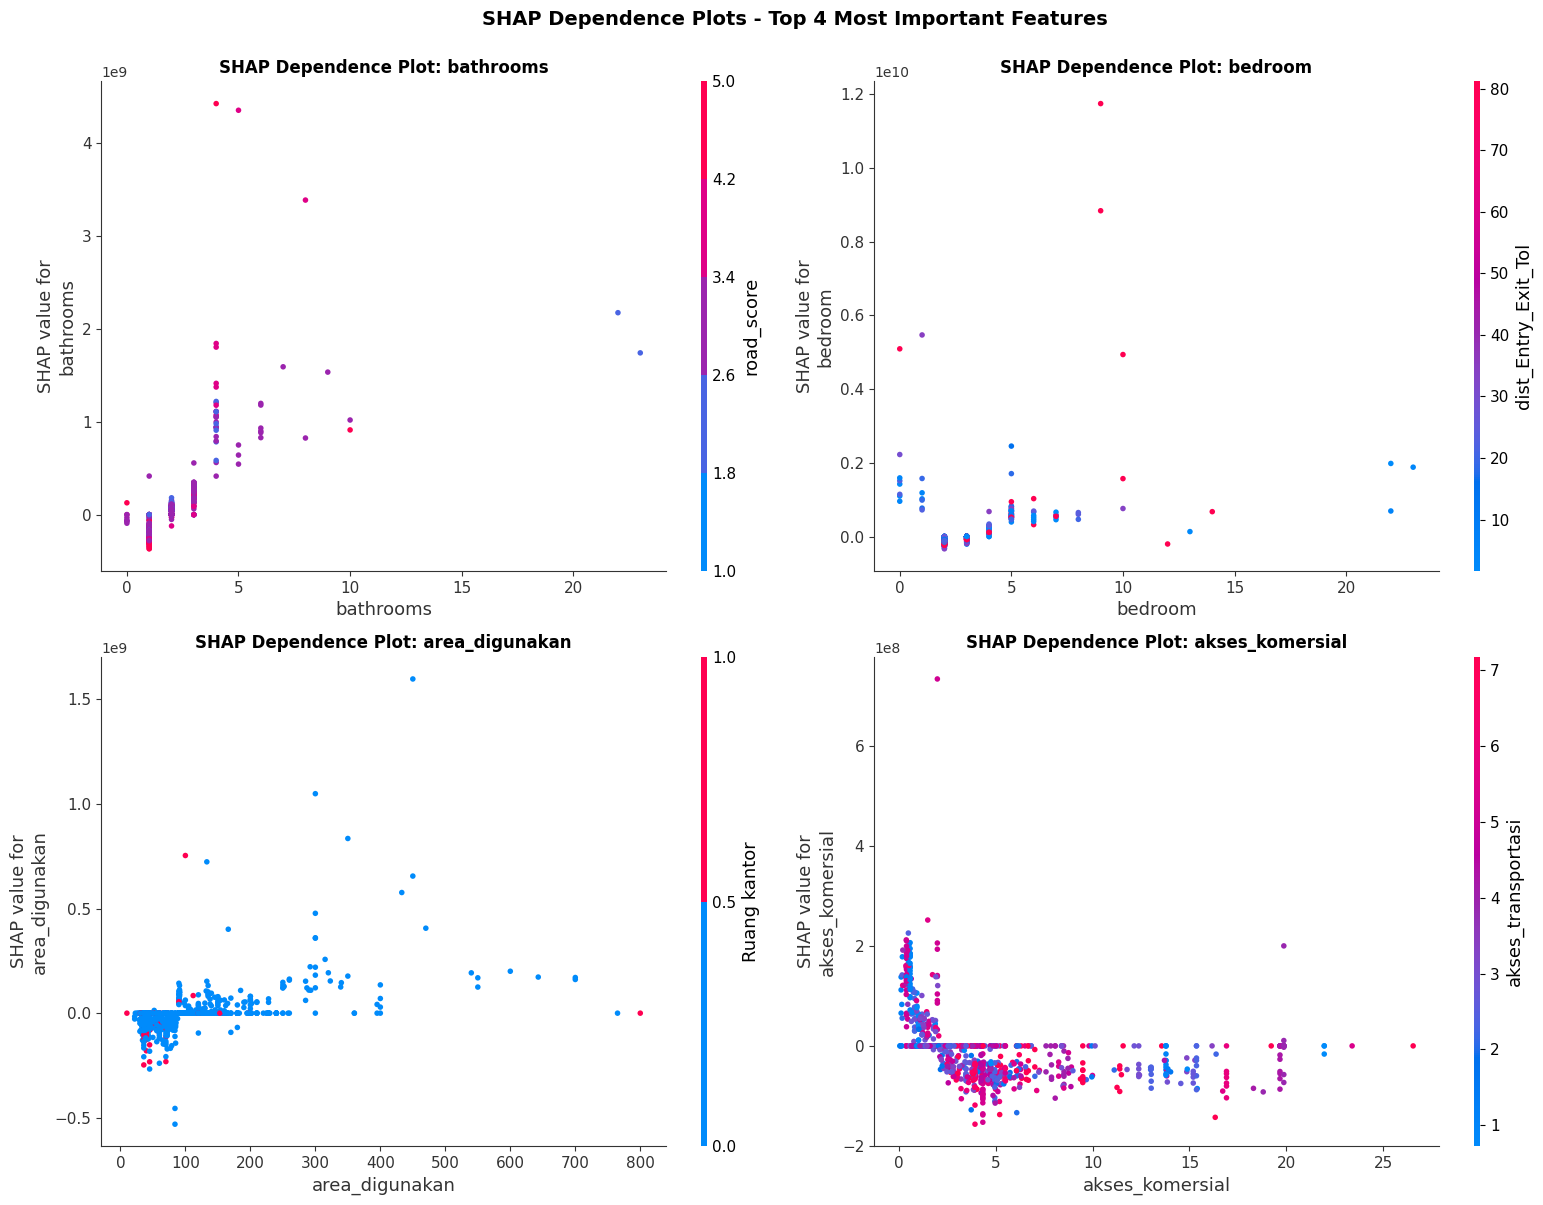

In [29]:
# SHAP Dependence Plot - Top 4 features
if shap_values is not None:
    # Get top 4 features by mean absolute SHAP
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('importance', ascending=False)

    top_4_features = shap_importance.head(4)['feature'].tolist()
    top_4_indices = [feature_names.index(f) for f in top_4_features]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, (feature, feat_idx) in enumerate(zip(top_4_features, top_4_indices)):
        plt.sca(axes[i])
        shap.dependence_plot(
            feat_idx,
            shap_values,
            X_shap_np,
            feature_names=feature_names,
            interaction_index="auto",
            show=False,
            ax=axes[i]
        )
        axes[i].set_title(f'SHAP Dependence Plot: {feature}', fontsize=12, fontweight='bold')

    plt.suptitle('SHAP Dependence Plots - Top 4 Most Important Features', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping dependence plots.")

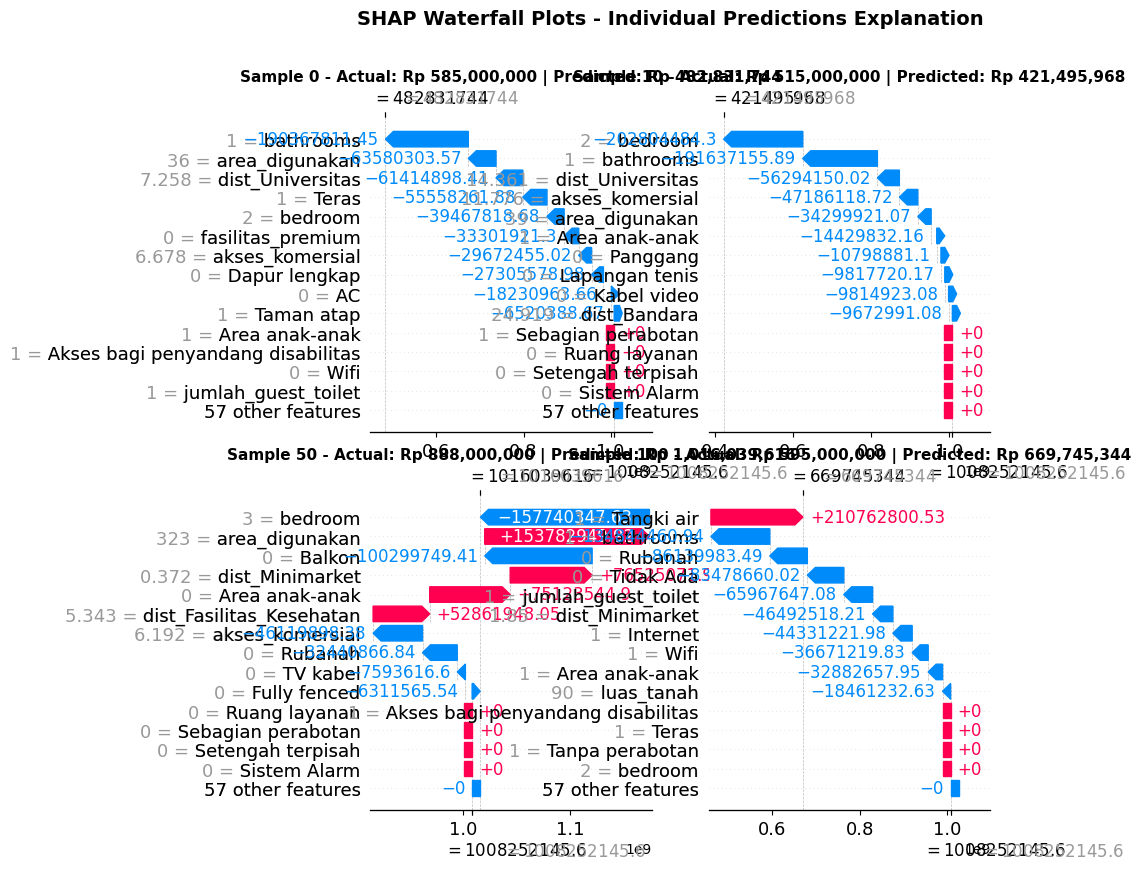

In [30]:
# SHAP Waterfall Plot - Contoh prediksi individual
if shap_values is not None and expected_value is not None:
    sample_idx = [0, 10, 50, 100]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, idx in enumerate(sample_idx):
        if idx < len(X_shap_np):
            plt.sca(axes[i])
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values[idx],
                    base_values=float(expected_value),
                    data=X_shap_np[idx],
                    feature_names=feature_names
                ),
                max_display=15,
                show=False
            )
            
            actual_price = y_shap_np[idx]
            predicted_price = train_pred[idx]
            axes[i].set_title(f'Sample {idx} - Actual: Rp {actual_price:,.0f} | Predicted: Rp {predicted_price:,.0f}', 
                             fontsize=11, fontweight='bold')

    plt.suptitle('SHAP Waterfall Plots - Individual Predictions Explanation', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping waterfall plots.")

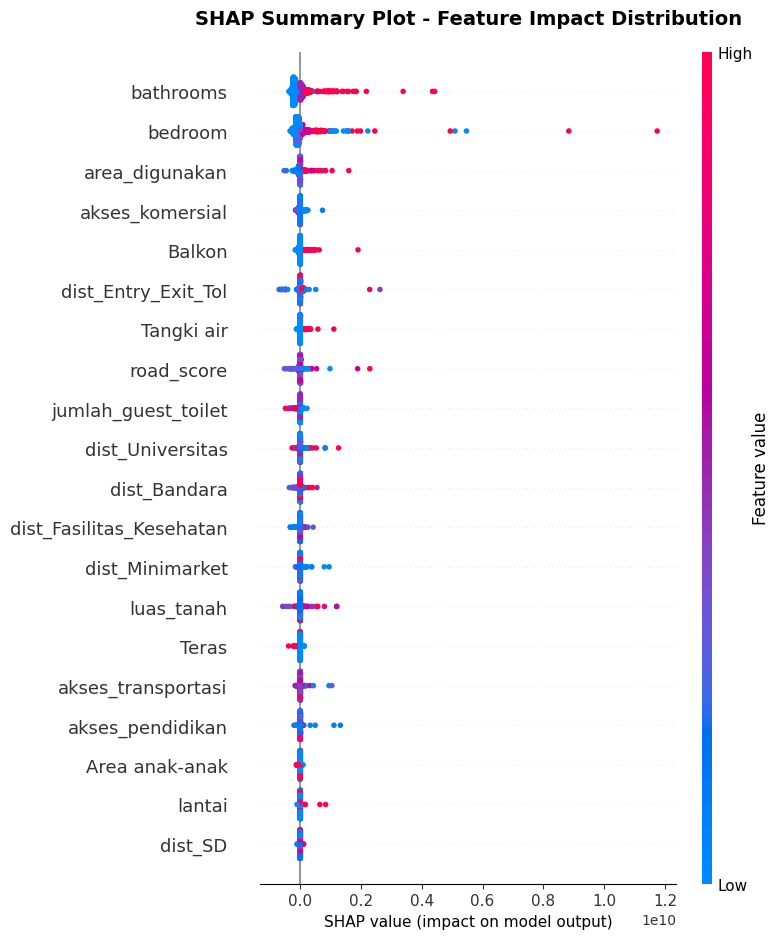

In [31]:
# SHAP Summary Plot - Beeswarm (Feature Impact Distribution)
if shap_values is not None:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap_np, feature_names=feature_names, max_display=20, show=False)
    plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('SHAP value (impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping beeswarm plot.")

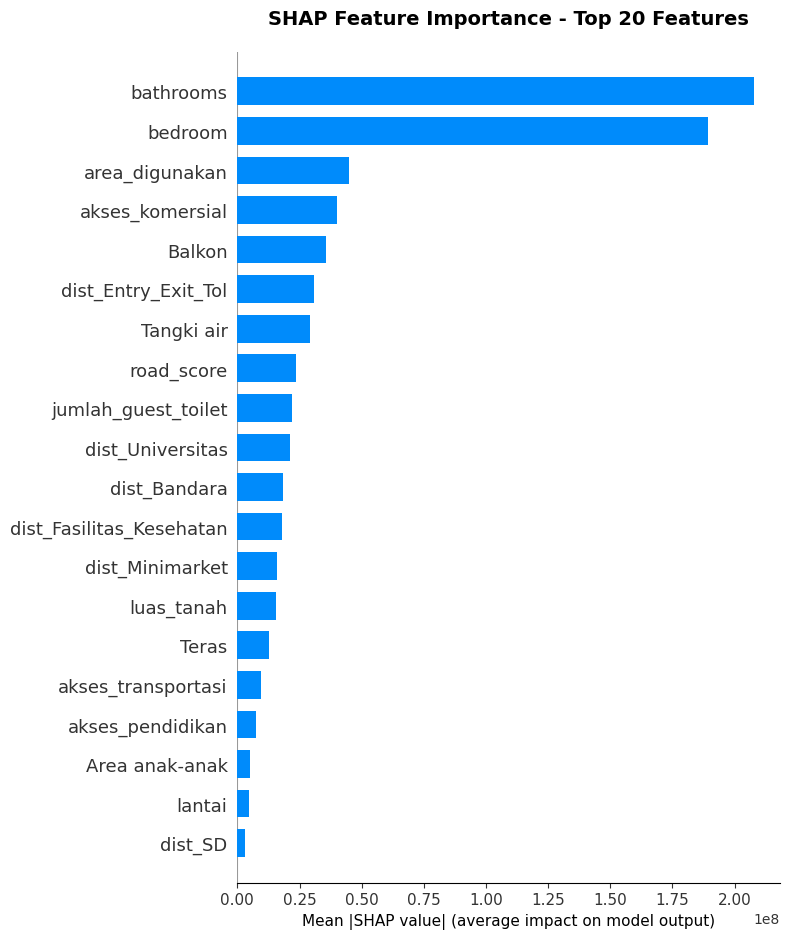

In [32]:
# SHAP Summary Plot - Bar (Feature Importance)
if shap_values is not None:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap_np, feature_names=feature_names, plot_type="bar", max_display=20, show=False)
    plt.title('SHAP Feature Importance - Top 20 Features', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Mean |SHAP value| (average impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping bar plot.")

## CatBoost

In [8]:
from catboost import CatBoostRegressor

In [9]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [10]:
# TARGET & FEATURE untuk CatBoost
y_train_CB = df_train["Harga_Asli"]
X_train_CB = df_train.drop(columns=["Harga_Asli", "latitude", "longitude", "sample_weight"])

y_test_CB = df_test["Harga_Asli"]
X_test_CB = df_test.drop(columns=["Harga_Asli", "latitude", "longitude"])

# Tentukan categorical features
cat_features = ["kecamatan"]
groups_cb = df_train["kecamatan"]

In [11]:
catboost_model = CatBoostRegressor(
    loss_function='RMSE',
    cat_features=cat_features,
    task_type='GPU',           # 👈 Aktifkan GPU
    devices='0',               # 👈 Device 0 (karena CUDA_VISIBLE_DEVICES="1" sudah set ke GPU fisik 1)
    gpu_ram_part=0.5,          # 👈 Gunakan 50% GPU RAM (sesuaikan jika perlu)
    verbose=0,
    random_state=42,
    # GPU-specific optimizations
    max_ctr_complexity=4
)

param_dist_cb = {
    "iterations": randint(300, 800),
    "depth": randint(4, 10),
    "learning_rate": uniform(0.01, 0.2),
    "l2_leaf_reg": uniform(1, 10),
    "border_count": [32, 64, 128, 254],
    "bagging_temperature": uniform(0, 1),
    "random_strength": uniform(0, 2),
    "learning_rate": uniform(0.01, 0.2),
    "l2_leaf_reg": uniform(1, 10),
    "border_count": [32, 64, 128, 254],
    "bagging_temperature": uniform(0, 1),
    "random_strength": uniform(0, 2),
    "bootstrap_type": ['MVS']
}

### Cross Validation

In [12]:
import warnings
warnings.filterwarnings('ignore')

cv = GroupKFold(n_splits=5)

random_search_cb = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=param_dist_cb,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=1,
    error_score="raise"
)

random_search_cb.fit(
    X_train_CB,
    y_train_CB,
    groups=groups_cb,  # 👈 Karena kecamatan masih ada di X_train_CB
    sample_weight=sample_weight_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   5.2s


[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   4.9s


[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   5.4s


[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   4.9s


[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   4.4s


[CV] END bagging_temperature=0.05808361216819946, bootstrap_type=MVS, border_count=254, depth=8, iterations=399, l2_leaf_reg=2.428668179219408, learning_rate=0.14017769458977059, random_strength=0.11282315805420051; total time=   8.2s


[CV] END bagging_temperature=0.05808361216819946, bootstrap_type=MVS, border_count=254, depth=8, iterations=399, l2_leaf_reg=2.428668179219408, learning_rate=0.14017769458977059, random_strength=0.11282315805420051; total time=   7.9s


[CV] END bagging_temperature=0.05808361216819946, bootstrap_type=MVS, border_count=254, depth=8, iterations=399, l2_leaf_reg=2.428668179219408, learning_rate=0.14017769458977059, random_strength=0.11282315805420051; total time=   7.7s


[CV] END bagging_temperature=0.05808361216819946, bootstrap_type=MVS, border_count=254, depth=8, iterations=399, l2_leaf_reg=2.428668179219408, learning_rate=0.14017769458977059, random_strength=0.11282315805420051; total time=   8.2s


[CV] END bagging_temperature=0.05808361216819946, bootstrap_type=MVS, border_count=254, depth=8, iterations=399, l2_leaf_reg=2.428668179219408, learning_rate=0.14017769458977059, random_strength=0.11282315805420051; total time=   8.1s


[CV] END bagging_temperature=0.7219987722668247, bootstrap_type=MVS, border_count=64, depth=9, iterations=685, l2_leaf_reg=2.818249672071006, learning_rate=0.046680901970686764, random_strength=0.6084844859190754; total time=  41.5s


[CV] END bagging_temperature=0.7219987722668247, bootstrap_type=MVS, border_count=64, depth=9, iterations=685, l2_leaf_reg=2.818249672071006, learning_rate=0.046680901970686764, random_strength=0.6084844859190754; total time=  41.8s


[CV] END bagging_temperature=0.7219987722668247, bootstrap_type=MVS, border_count=64, depth=9, iterations=685, l2_leaf_reg=2.818249672071006, learning_rate=0.046680901970686764, random_strength=0.6084844859190754; total time=  38.6s


[CV] END bagging_temperature=0.7219987722668247, bootstrap_type=MVS, border_count=64, depth=9, iterations=685, l2_leaf_reg=2.818249672071006, learning_rate=0.046680901970686764, random_strength=0.6084844859190754; total time=  42.0s


[CV] END bagging_temperature=0.7219987722668247, bootstrap_type=MVS, border_count=64, depth=9, iterations=685, l2_leaf_reg=2.818249672071006, learning_rate=0.046680901970686764, random_strength=0.6084844859190754; total time=  33.5s


[CV] END bagging_temperature=0.5247564316322378, bootstrap_type=MVS, border_count=254, depth=4, iterations=348, l2_leaf_reg=6.2477466025838915, learning_rate=0.08997219434305109, random_strength=0.09333132642723085; total time=   3.0s


[CV] END bagging_temperature=0.5247564316322378, bootstrap_type=MVS, border_count=254, depth=4, iterations=348, l2_leaf_reg=6.2477466025838915, learning_rate=0.08997219434305109, random_strength=0.09333132642723085; total time=   3.0s


[CV] END bagging_temperature=0.5247564316322378, bootstrap_type=MVS, border_count=254, depth=4, iterations=348, l2_leaf_reg=6.2477466025838915, learning_rate=0.08997219434305109, random_strength=0.09333132642723085; total time=   3.1s


[CV] END bagging_temperature=0.5247564316322378, bootstrap_type=MVS, border_count=254, depth=4, iterations=348, l2_leaf_reg=6.2477466025838915, learning_rate=0.08997219434305109, random_strength=0.09333132642723085; total time=   3.4s


[CV] END bagging_temperature=0.5247564316322378, bootstrap_type=MVS, border_count=254, depth=4, iterations=348, l2_leaf_reg=6.2477466025838915, learning_rate=0.08997219434305109, random_strength=0.09333132642723085; total time=   3.0s


[CV] END bagging_temperature=0.9737555188414592, bootstrap_type=MVS, border_count=128, depth=9, iterations=745, l2_leaf_reg=8.851759613930136, learning_rate=0.04993475643167195, random_strength=1.0284688768272232; total time=  42.8s


[CV] END bagging_temperature=0.9737555188414592, bootstrap_type=MVS, border_count=128, depth=9, iterations=745, l2_leaf_reg=8.851759613930136, learning_rate=0.04993475643167195, random_strength=1.0284688768272232; total time=  49.0s


[CV] END bagging_temperature=0.9737555188414592, bootstrap_type=MVS, border_count=128, depth=9, iterations=745, l2_leaf_reg=8.851759613930136, learning_rate=0.04993475643167195, random_strength=1.0284688768272232; total time=  51.2s


[CV] END bagging_temperature=0.9737555188414592, bootstrap_type=MVS, border_count=128, depth=9, iterations=745, l2_leaf_reg=8.851759613930136, learning_rate=0.04993475643167195, random_strength=1.0284688768272232; total time=  49.6s


[CV] END bagging_temperature=0.9737555188414592, bootstrap_type=MVS, border_count=128, depth=9, iterations=745, l2_leaf_reg=8.851759613930136, learning_rate=0.04993475643167195, random_strength=1.0284688768272232; total time=  49.1s


[CV] END bagging_temperature=0.5924145688620425, bootstrap_type=MVS, border_count=128, depth=8, iterations=606, l2_leaf_reg=7.803075385877797, learning_rate=0.1000998503939086, random_strength=0.026529922319733057; total time=  26.1s


[CV] END bagging_temperature=0.5924145688620425, bootstrap_type=MVS, border_count=128, depth=8, iterations=606, l2_leaf_reg=7.803075385877797, learning_rate=0.1000998503939086, random_strength=0.026529922319733057; total time=  26.4s


[CV] END bagging_temperature=0.5924145688620425, bootstrap_type=MVS, border_count=128, depth=8, iterations=606, l2_leaf_reg=7.803075385877797, learning_rate=0.1000998503939086, random_strength=0.026529922319733057; total time=  25.5s


[CV] END bagging_temperature=0.5924145688620425, bootstrap_type=MVS, border_count=128, depth=8, iterations=606, l2_leaf_reg=7.803075385877797, learning_rate=0.1000998503939086, random_strength=0.026529922319733057; total time=  26.6s


[CV] END bagging_temperature=0.5924145688620425, bootstrap_type=MVS, border_count=128, depth=8, iterations=606, l2_leaf_reg=7.803075385877797, learning_rate=0.1000998503939086, random_strength=0.026529922319733057; total time=  26.9s


[CV] END bagging_temperature=0.9422017556848528, bootstrap_type=MVS, border_count=64, depth=5, iterations=564, l2_leaf_reg=1.159662522202142, learning_rate=0.056178765124429805, random_strength=0.48205093205202343; total time=   9.1s


[CV] END bagging_temperature=0.9422017556848528, bootstrap_type=MVS, border_count=64, depth=5, iterations=564, l2_leaf_reg=1.159662522202142, learning_rate=0.056178765124429805, random_strength=0.48205093205202343; total time=   9.0s


[CV] END bagging_temperature=0.9422017556848528, bootstrap_type=MVS, border_count=64, depth=5, iterations=564, l2_leaf_reg=1.159662522202142, learning_rate=0.056178765124429805, random_strength=0.48205093205202343; total time=   8.7s


[CV] END bagging_temperature=0.9422017556848528, bootstrap_type=MVS, border_count=64, depth=5, iterations=564, l2_leaf_reg=1.159662522202142, learning_rate=0.056178765124429805, random_strength=0.48205093205202343; total time=   9.8s


[CV] END bagging_temperature=0.9422017556848528, bootstrap_type=MVS, border_count=64, depth=5, iterations=564, l2_leaf_reg=1.159662522202142, learning_rate=0.056178765124429805, random_strength=0.48205093205202343; total time=   9.4s


[CV] END bagging_temperature=0.6832635188254582, bootstrap_type=MVS, border_count=254, depth=8, iterations=563, l2_leaf_reg=1.343885211152184, learning_rate=0.19186408041575642, random_strength=0.5175599632000338; total time=  24.5s


[CV] END bagging_temperature=0.6832635188254582, bootstrap_type=MVS, border_count=254, depth=8, iterations=563, l2_leaf_reg=1.343885211152184, learning_rate=0.19186408041575642, random_strength=0.5175599632000338; total time=  22.5s


[CV] END bagging_temperature=0.6832635188254582, bootstrap_type=MVS, border_count=254, depth=8, iterations=563, l2_leaf_reg=1.343885211152184, learning_rate=0.19186408041575642, random_strength=0.5175599632000338; total time=  22.7s


[CV] END bagging_temperature=0.6832635188254582, bootstrap_type=MVS, border_count=254, depth=8, iterations=563, l2_leaf_reg=1.343885211152184, learning_rate=0.19186408041575642, random_strength=0.5175599632000338; total time=  24.7s


[CV] END bagging_temperature=0.6832635188254582, bootstrap_type=MVS, border_count=254, depth=8, iterations=563, l2_leaf_reg=1.343885211152184, learning_rate=0.19186408041575642, random_strength=0.5175599632000338; total time=  24.6s


[CV] END bagging_temperature=0.662522284353982, bootstrap_type=MVS, border_count=64, depth=9, iterations=689, l2_leaf_reg=3.079416628681888, learning_rate=0.1235400655639983, random_strength=0.06262658491111717; total time=  33.0s


[CV] END bagging_temperature=0.662522284353982, bootstrap_type=MVS, border_count=64, depth=9, iterations=689, l2_leaf_reg=3.079416628681888, learning_rate=0.1235400655639983, random_strength=0.06262658491111717; total time=  43.2s


[CV] END bagging_temperature=0.662522284353982, bootstrap_type=MVS, border_count=64, depth=9, iterations=689, l2_leaf_reg=3.079416628681888, learning_rate=0.1235400655639983, random_strength=0.06262658491111717; total time=  27.9s


[CV] END bagging_temperature=0.662522284353982, bootstrap_type=MVS, border_count=64, depth=9, iterations=689, l2_leaf_reg=3.079416628681888, learning_rate=0.1235400655639983, random_strength=0.06262658491111717; total time=  46.3s


[CV] END bagging_temperature=0.662522284353982, bootstrap_type=MVS, border_count=64, depth=9, iterations=689, l2_leaf_reg=3.079416628681888, learning_rate=0.1235400655639983, random_strength=0.06262658491111717; total time=  39.7s


[CV] END bagging_temperature=0.8422847745949985, bootstrap_type=MVS, border_count=254, depth=5, iterations=501, l2_leaf_reg=9.948273504276488, learning_rate=0.12957999576221704, random_strength=1.8437484700462337; total time=   8.9s


[CV] END bagging_temperature=0.8422847745949985, bootstrap_type=MVS, border_count=254, depth=5, iterations=501, l2_leaf_reg=9.948273504276488, learning_rate=0.12957999576221704, random_strength=1.8437484700462337; total time=   9.7s


[CV] END bagging_temperature=0.8422847745949985, bootstrap_type=MVS, border_count=254, depth=5, iterations=501, l2_leaf_reg=9.948273504276488, learning_rate=0.12957999576221704, random_strength=1.8437484700462337; total time=   9.7s


[CV] END bagging_temperature=0.8422847745949985, bootstrap_type=MVS, border_count=254, depth=5, iterations=501, l2_leaf_reg=9.948273504276488, learning_rate=0.12957999576221704, random_strength=1.8437484700462337; total time=  10.1s


[CV] END bagging_temperature=0.8422847745949985, bootstrap_type=MVS, border_count=254, depth=5, iterations=501, l2_leaf_reg=9.948273504276488, learning_rate=0.12957999576221704, random_strength=1.8437484700462337; total time=  10.7s


[CV] END bagging_temperature=0.0884925020519195, bootstrap_type=MVS, border_count=128, depth=7, iterations=489, l2_leaf_reg=4.253303307632644, learning_rate=0.0877354579378964, random_strength=0.5426980635477918; total time=  12.2s


[CV] END bagging_temperature=0.0884925020519195, bootstrap_type=MVS, border_count=128, depth=7, iterations=489, l2_leaf_reg=4.253303307632644, learning_rate=0.0877354579378964, random_strength=0.5426980635477918; total time=   9.2s


[CV] END bagging_temperature=0.0884925020519195, bootstrap_type=MVS, border_count=128, depth=7, iterations=489, l2_leaf_reg=4.253303307632644, learning_rate=0.0877354579378964, random_strength=0.5426980635477918; total time=   9.0s


[CV] END bagging_temperature=0.0884925020519195, bootstrap_type=MVS, border_count=128, depth=7, iterations=489, l2_leaf_reg=4.253303307632644, learning_rate=0.0877354579378964, random_strength=0.5426980635477918; total time=   9.4s


[CV] END bagging_temperature=0.0884925020519195, bootstrap_type=MVS, border_count=128, depth=7, iterations=489, l2_leaf_reg=4.253303307632644, learning_rate=0.0877354579378964, random_strength=0.5426980635477918; total time=   8.8s


[CV] END bagging_temperature=0.8287375091519293, bootstrap_type=MVS, border_count=64, depth=4, iterations=551, l2_leaf_reg=7.070342476866847, learning_rate=0.06519983640450867, random_strength=0.5925470114081648; total time=   8.2s


[CV] END bagging_temperature=0.8287375091519293, bootstrap_type=MVS, border_count=64, depth=4, iterations=551, l2_leaf_reg=7.070342476866847, learning_rate=0.06519983640450867, random_strength=0.5925470114081648; total time=   7.9s


[CV] END bagging_temperature=0.8287375091519293, bootstrap_type=MVS, border_count=64, depth=4, iterations=551, l2_leaf_reg=7.070342476866847, learning_rate=0.06519983640450867, random_strength=0.5925470114081648; total time=   8.8s


[CV] END bagging_temperature=0.8287375091519293, bootstrap_type=MVS, border_count=64, depth=4, iterations=551, l2_leaf_reg=7.070342476866847, learning_rate=0.06519983640450867, random_strength=0.5925470114081648; total time=   8.7s


[CV] END bagging_temperature=0.8287375091519293, bootstrap_type=MVS, border_count=64, depth=4, iterations=551, l2_leaf_reg=7.070342476866847, learning_rate=0.06519983640450867, random_strength=0.5925470114081648; total time=   8.2s


[CV] END bagging_temperature=0.1652669390630025, bootstrap_type=MVS, border_count=32, depth=4, iterations=643, l2_leaf_reg=4.948815181755697, learning_rate=0.06869763494360763, random_strength=0.02815964543016891; total time=   9.2s


[CV] END bagging_temperature=0.1652669390630025, bootstrap_type=MVS, border_count=32, depth=4, iterations=643, l2_leaf_reg=4.948815181755697, learning_rate=0.06869763494360763, random_strength=0.02815964543016891; total time=   9.6s


[CV] END bagging_temperature=0.1652669390630025, bootstrap_type=MVS, border_count=32, depth=4, iterations=643, l2_leaf_reg=4.948815181755697, learning_rate=0.06869763494360763, random_strength=0.02815964543016891; total time=   8.9s


[CV] END bagging_temperature=0.1652669390630025, bootstrap_type=MVS, border_count=32, depth=4, iterations=643, l2_leaf_reg=4.948815181755697, learning_rate=0.06869763494360763, random_strength=0.02815964543016891; total time=  10.0s


[CV] END bagging_temperature=0.1652669390630025, bootstrap_type=MVS, border_count=32, depth=4, iterations=643, l2_leaf_reg=4.948815181755697, learning_rate=0.06869763494360763, random_strength=0.02815964543016891; total time=   9.5s


[CV] END bagging_temperature=0.19884240408880516, bootstrap_type=MVS, border_count=254, depth=6, iterations=718, l2_leaf_reg=8.712703466859457, learning_rate=0.024808930346818074, random_strength=0.7169314570885452; total time=  16.9s


[CV] END bagging_temperature=0.19884240408880516, bootstrap_type=MVS, border_count=254, depth=6, iterations=718, l2_leaf_reg=8.712703466859457, learning_rate=0.024808930346818074, random_strength=0.7169314570885452; total time=  17.3s


[CV] END bagging_temperature=0.19884240408880516, bootstrap_type=MVS, border_count=254, depth=6, iterations=718, l2_leaf_reg=8.712703466859457, learning_rate=0.024808930346818074, random_strength=0.7169314570885452; total time=  17.5s


[CV] END bagging_temperature=0.19884240408880516, bootstrap_type=MVS, border_count=254, depth=6, iterations=718, l2_leaf_reg=8.712703466859457, learning_rate=0.024808930346818074, random_strength=0.7169314570885452; total time=  18.9s


[CV] END bagging_temperature=0.19884240408880516, bootstrap_type=MVS, border_count=254, depth=6, iterations=718, l2_leaf_reg=8.712703466859457, learning_rate=0.024808930346818074, random_strength=0.7169314570885452; total time=  17.9s


[CV] END bagging_temperature=0.11586905952512971, bootstrap_type=MVS, border_count=128, depth=4, iterations=627, l2_leaf_reg=5.494506741382034, learning_rate=0.029082023298082266, random_strength=0.7416365043965327; total time=  10.3s


[CV] END bagging_temperature=0.11586905952512971, bootstrap_type=MVS, border_count=128, depth=4, iterations=627, l2_leaf_reg=5.494506741382034, learning_rate=0.029082023298082266, random_strength=0.7416365043965327; total time=   9.4s


[CV] END bagging_temperature=0.11586905952512971, bootstrap_type=MVS, border_count=128, depth=4, iterations=627, l2_leaf_reg=5.494506741382034, learning_rate=0.029082023298082266, random_strength=0.7416365043965327; total time=   9.7s


[CV] END bagging_temperature=0.11586905952512971, bootstrap_type=MVS, border_count=128, depth=4, iterations=627, l2_leaf_reg=5.494506741382034, learning_rate=0.029082023298082266, random_strength=0.7416365043965327; total time=   9.1s


[CV] END bagging_temperature=0.11586905952512971, bootstrap_type=MVS, border_count=128, depth=4, iterations=627, l2_leaf_reg=5.494506741382034, learning_rate=0.029082023298082266, random_strength=0.7416365043965327; total time=   9.4s


[CV] END bagging_temperature=0.6688412526636073, bootstrap_type=MVS, border_count=32, depth=6, iterations=471, l2_leaf_reg=7.3755747135521315, learning_rate=0.18744254851526532, random_strength=0.9444298503238986; total time=   7.6s


[CV] END bagging_temperature=0.6688412526636073, bootstrap_type=MVS, border_count=32, depth=6, iterations=471, l2_leaf_reg=7.3755747135521315, learning_rate=0.18744254851526532, random_strength=0.9444298503238986; total time=   7.3s


[CV] END bagging_temperature=0.6688412526636073, bootstrap_type=MVS, border_count=32, depth=6, iterations=471, l2_leaf_reg=7.3755747135521315, learning_rate=0.18744254851526532, random_strength=0.9444298503238986; total time=   7.5s


[CV] END bagging_temperature=0.6688412526636073, bootstrap_type=MVS, border_count=32, depth=6, iterations=471, l2_leaf_reg=7.3755747135521315, learning_rate=0.18744254851526532, random_strength=0.9444298503238986; total time=   9.4s


[CV] END bagging_temperature=0.6688412526636073, bootstrap_type=MVS, border_count=32, depth=6, iterations=471, l2_leaf_reg=7.3755747135521315, learning_rate=0.18744254851526532, random_strength=0.9444298503238986; total time=   7.2s


[CV] END bagging_temperature=0.1195942459383017, bootstrap_type=MVS, border_count=64, depth=6, iterations=556, l2_leaf_reg=8.217295211648732, learning_rate=0.057196983949791155, random_strength=0.5121366455226479; total time=  14.0s


[CV] END bagging_temperature=0.1195942459383017, bootstrap_type=MVS, border_count=64, depth=6, iterations=556, l2_leaf_reg=8.217295211648732, learning_rate=0.057196983949791155, random_strength=0.5121366455226479; total time=  13.3s


[CV] END bagging_temperature=0.1195942459383017, bootstrap_type=MVS, border_count=64, depth=6, iterations=556, l2_leaf_reg=8.217295211648732, learning_rate=0.057196983949791155, random_strength=0.5121366455226479; total time=  14.3s


[CV] END bagging_temperature=0.1195942459383017, bootstrap_type=MVS, border_count=64, depth=6, iterations=556, l2_leaf_reg=8.217295211648732, learning_rate=0.057196983949791155, random_strength=0.5121366455226479; total time=  14.2s


[CV] END bagging_temperature=0.1195942459383017, bootstrap_type=MVS, border_count=64, depth=6, iterations=556, l2_leaf_reg=8.217295211648732, learning_rate=0.057196983949791155, random_strength=0.5121366455226479; total time=  13.9s


[CV] END bagging_temperature=0.04043358953843135, bootstrap_type=MVS, border_count=128, depth=5, iterations=341, l2_leaf_reg=5.393365018657701, learning_rate=0.050343840467079244, random_strength=1.7915271913470387; total time=   4.7s


[CV] END bagging_temperature=0.04043358953843135, bootstrap_type=MVS, border_count=128, depth=5, iterations=341, l2_leaf_reg=5.393365018657701, learning_rate=0.050343840467079244, random_strength=1.7915271913470387; total time=   4.8s


[CV] END bagging_temperature=0.04043358953843135, bootstrap_type=MVS, border_count=128, depth=5, iterations=341, l2_leaf_reg=5.393365018657701, learning_rate=0.050343840467079244, random_strength=1.7915271913470387; total time=   5.0s


[CV] END bagging_temperature=0.04043358953843135, bootstrap_type=MVS, border_count=128, depth=5, iterations=341, l2_leaf_reg=5.393365018657701, learning_rate=0.050343840467079244, random_strength=1.7915271913470387; total time=   4.5s


[CV] END bagging_temperature=0.04043358953843135, bootstrap_type=MVS, border_count=128, depth=5, iterations=341, l2_leaf_reg=5.393365018657701, learning_rate=0.050343840467079244, random_strength=1.7915271913470387; total time=   5.0s


[CV] END bagging_temperature=0.47537022318211175, bootstrap_type=MVS, border_count=32, depth=7, iterations=521, l2_leaf_reg=2.393314544058757, learning_rate=0.13088347585556345, random_strength=1.0796821826033463; total time=  15.5s


[CV] END bagging_temperature=0.47537022318211175, bootstrap_type=MVS, border_count=32, depth=7, iterations=521, l2_leaf_reg=2.393314544058757, learning_rate=0.13088347585556345, random_strength=1.0796821826033463; total time=  15.5s


[CV] END bagging_temperature=0.47537022318211175, bootstrap_type=MVS, border_count=32, depth=7, iterations=521, l2_leaf_reg=2.393314544058757, learning_rate=0.13088347585556345, random_strength=1.0796821826033463; total time=  15.5s


[CV] END bagging_temperature=0.47537022318211175, bootstrap_type=MVS, border_count=32, depth=7, iterations=521, l2_leaf_reg=2.393314544058757, learning_rate=0.13088347585556345, random_strength=1.0796821826033463; total time=  16.3s


[CV] END bagging_temperature=0.47537022318211175, bootstrap_type=MVS, border_count=32, depth=7, iterations=521, l2_leaf_reg=2.393314544058757, learning_rate=0.13088347585556345, random_strength=1.0796821826033463; total time=  11.6s


[CV] END bagging_temperature=0.2030612247347694, bootstrap_type=MVS, border_count=32, depth=6, iterations=542, l2_leaf_reg=2.612212872540044, learning_rate=0.19593953046851464, random_strength=1.616240759128834; total time=  11.6s


[CV] END bagging_temperature=0.2030612247347694, bootstrap_type=MVS, border_count=32, depth=6, iterations=542, l2_leaf_reg=2.612212872540044, learning_rate=0.19593953046851464, random_strength=1.616240759128834; total time=  11.9s


[CV] END bagging_temperature=0.2030612247347694, bootstrap_type=MVS, border_count=32, depth=6, iterations=542, l2_leaf_reg=2.612212872540044, learning_rate=0.19593953046851464, random_strength=1.616240759128834; total time=  11.8s


[CV] END bagging_temperature=0.2030612247347694, bootstrap_type=MVS, border_count=32, depth=6, iterations=542, l2_leaf_reg=2.612212872540044, learning_rate=0.19593953046851464, random_strength=1.616240759128834; total time=  11.1s


[CV] END bagging_temperature=0.2030612247347694, bootstrap_type=MVS, border_count=32, depth=6, iterations=542, l2_leaf_reg=2.612212872540044, learning_rate=0.19593953046851464, random_strength=1.616240759128834; total time=  11.0s


[CV] END bagging_temperature=0.6334037565104235, bootstrap_type=MVS, border_count=64, depth=7, iterations=327, l2_leaf_reg=3.184404372168336, learning_rate=0.09330198957407325, random_strength=1.7665605178377366; total time=   5.6s


[CV] END bagging_temperature=0.6334037565104235, bootstrap_type=MVS, border_count=64, depth=7, iterations=327, l2_leaf_reg=3.184404372168336, learning_rate=0.09330198957407325, random_strength=1.7665605178377366; total time=   5.5s


[CV] END bagging_temperature=0.6334037565104235, bootstrap_type=MVS, border_count=64, depth=7, iterations=327, l2_leaf_reg=3.184404372168336, learning_rate=0.09330198957407325, random_strength=1.7665605178377366; total time=   5.3s


[CV] END bagging_temperature=0.6334037565104235, bootstrap_type=MVS, border_count=64, depth=7, iterations=327, l2_leaf_reg=3.184404372168336, learning_rate=0.09330198957407325, random_strength=1.7665605178377366; total time=   5.6s


[CV] END bagging_temperature=0.6334037565104235, bootstrap_type=MVS, border_count=64, depth=7, iterations=327, l2_leaf_reg=3.184404372168336, learning_rate=0.09330198957407325, random_strength=1.7665605178377366; total time=   5.6s


[CV] END bagging_temperature=0.32434502100527396, bootstrap_type=MVS, border_count=128, depth=7, iterations=772, l2_leaf_reg=4.180034749718638, learning_rate=0.03201038490553535, random_strength=0.45587032508388337; total time=  23.3s


[CV] END bagging_temperature=0.32434502100527396, bootstrap_type=MVS, border_count=128, depth=7, iterations=772, l2_leaf_reg=4.180034749718638, learning_rate=0.03201038490553535, random_strength=0.45587032508388337; total time=  22.6s


[CV] END bagging_temperature=0.32434502100527396, bootstrap_type=MVS, border_count=128, depth=7, iterations=772, l2_leaf_reg=4.180034749718638, learning_rate=0.03201038490553535, random_strength=0.45587032508388337; total time=  20.5s


[CV] END bagging_temperature=0.32434502100527396, bootstrap_type=MVS, border_count=128, depth=7, iterations=772, l2_leaf_reg=4.180034749718638, learning_rate=0.03201038490553535, random_strength=0.45587032508388337; total time=  23.2s


[CV] END bagging_temperature=0.32434502100527396, bootstrap_type=MVS, border_count=128, depth=7, iterations=772, l2_leaf_reg=4.180034749718638, learning_rate=0.03201038490553535, random_strength=0.45587032508388337; total time=  22.0s


[CV] END bagging_temperature=0.4271077886262563, bootstrap_type=MVS, border_count=254, depth=8, iterations=532, l2_leaf_reg=4.04781258158029, learning_rate=0.04293117062858835, random_strength=1.068178838750884; total time=  23.6s


[CV] END bagging_temperature=0.4271077886262563, bootstrap_type=MVS, border_count=254, depth=8, iterations=532, l2_leaf_reg=4.04781258158029, learning_rate=0.04293117062858835, random_strength=1.068178838750884; total time=  23.2s


[CV] END bagging_temperature=0.4271077886262563, bootstrap_type=MVS, border_count=254, depth=8, iterations=532, l2_leaf_reg=4.04781258158029, learning_rate=0.04293117062858835, random_strength=1.068178838750884; total time=  23.3s


[CV] END bagging_temperature=0.4271077886262563, bootstrap_type=MVS, border_count=254, depth=8, iterations=532, l2_leaf_reg=4.04781258158029, learning_rate=0.04293117062858835, random_strength=1.068178838750884; total time=  23.7s


[CV] END bagging_temperature=0.4271077886262563, bootstrap_type=MVS, border_count=254, depth=8, iterations=532, l2_leaf_reg=4.04781258158029, learning_rate=0.04293117062858835, random_strength=1.068178838750884; total time=  22.7s


[CV] END bagging_temperature=0.4848299713589832, bootstrap_type=MVS, border_count=32, depth=6, iterations=533, l2_leaf_reg=4.376151714036279, learning_rate=0.19858194078250385, random_strength=0.6464058640415105; total time=  11.8s


[CV] END bagging_temperature=0.4848299713589832, bootstrap_type=MVS, border_count=32, depth=6, iterations=533, l2_leaf_reg=4.376151714036279, learning_rate=0.19858194078250385, random_strength=0.6464058640415105; total time=  11.9s


[CV] END bagging_temperature=0.4848299713589832, bootstrap_type=MVS, border_count=32, depth=6, iterations=533, l2_leaf_reg=4.376151714036279, learning_rate=0.19858194078250385, random_strength=0.6464058640415105; total time=  11.7s


[CV] END bagging_temperature=0.4848299713589832, bootstrap_type=MVS, border_count=32, depth=6, iterations=533, l2_leaf_reg=4.376151714036279, learning_rate=0.19858194078250385, random_strength=0.6464058640415105; total time=  11.2s


[CV] END bagging_temperature=0.4848299713589832, bootstrap_type=MVS, border_count=32, depth=6, iterations=533, l2_leaf_reg=4.376151714036279, learning_rate=0.19858194078250385, random_strength=0.6464058640415105; total time=  10.6s


[CV] END bagging_temperature=0.5187906217433661, bootstrap_type=MVS, border_count=32, depth=7, iterations=412, l2_leaf_reg=1.6489224710898156, learning_rate=0.06078308278686894, random_strength=0.4937521256772024; total time=   6.6s


[CV] END bagging_temperature=0.5187906217433661, bootstrap_type=MVS, border_count=32, depth=7, iterations=412, l2_leaf_reg=1.6489224710898156, learning_rate=0.06078308278686894, random_strength=0.4937521256772024; total time=   6.3s


[CV] END bagging_temperature=0.5187906217433661, bootstrap_type=MVS, border_count=32, depth=7, iterations=412, l2_leaf_reg=1.6489224710898156, learning_rate=0.06078308278686894, random_strength=0.4937521256772024; total time=   6.8s


[CV] END bagging_temperature=0.5187906217433661, bootstrap_type=MVS, border_count=32, depth=7, iterations=412, l2_leaf_reg=1.6489224710898156, learning_rate=0.06078308278686894, random_strength=0.4937521256772024; total time=   6.4s


[CV] END bagging_temperature=0.5187906217433661, bootstrap_type=MVS, border_count=32, depth=7, iterations=412, l2_leaf_reg=1.6489224710898156, learning_rate=0.06078308278686894, random_strength=0.4937521256772024; total time=   6.8s


[CV] END bagging_temperature=0.6963042728397884, bootstrap_type=MVS, border_count=128, depth=4, iterations=400, l2_leaf_reg=3.848404943774676, learning_rate=0.01737738947090656, random_strength=1.2191286679597937; total time=   3.7s


[CV] END bagging_temperature=0.6963042728397884, bootstrap_type=MVS, border_count=128, depth=4, iterations=400, l2_leaf_reg=3.848404943774676, learning_rate=0.01737738947090656, random_strength=1.2191286679597937; total time=   4.1s


[CV] END bagging_temperature=0.6963042728397884, bootstrap_type=MVS, border_count=128, depth=4, iterations=400, l2_leaf_reg=3.848404943774676, learning_rate=0.01737738947090656, random_strength=1.2191286679597937; total time=   3.8s


[CV] END bagging_temperature=0.6963042728397884, bootstrap_type=MVS, border_count=128, depth=4, iterations=400, l2_leaf_reg=3.848404943774676, learning_rate=0.01737738947090656, random_strength=1.2191286679597937; total time=   4.6s


[CV] END bagging_temperature=0.6963042728397884, bootstrap_type=MVS, border_count=128, depth=4, iterations=400, l2_leaf_reg=3.848404943774676, learning_rate=0.01737738947090656, random_strength=1.2191286679597937; total time=   3.8s


[CV] END bagging_temperature=0.5026790232288615, bootstrap_type=MVS, border_count=64, depth=8, iterations=523, l2_leaf_reg=10.082658859666537, learning_rate=0.05791237813339449, random_strength=0.2897897441824462; total time=  15.8s


[CV] END bagging_temperature=0.5026790232288615, bootstrap_type=MVS, border_count=64, depth=8, iterations=523, l2_leaf_reg=10.082658859666537, learning_rate=0.05791237813339449, random_strength=0.2897897441824462; total time=  22.6s


[CV] END bagging_temperature=0.5026790232288615, bootstrap_type=MVS, border_count=64, depth=8, iterations=523, l2_leaf_reg=10.082658859666537, learning_rate=0.05791237813339449, random_strength=0.2897897441824462; total time=  22.4s


[CV] END bagging_temperature=0.5026790232288615, bootstrap_type=MVS, border_count=64, depth=8, iterations=523, l2_leaf_reg=10.082658859666537, learning_rate=0.05791237813339449, random_strength=0.2897897441824462; total time=  23.1s


[CV] END bagging_temperature=0.5026790232288615, bootstrap_type=MVS, border_count=64, depth=8, iterations=523, l2_leaf_reg=10.082658859666537, learning_rate=0.05791237813339449, random_strength=0.2897897441824462; total time=  21.8s


[CV] END bagging_temperature=0.489452760277563, bootstrap_type=MVS, border_count=254, depth=9, iterations=715, l2_leaf_reg=6.926967238793935, learning_rate=0.026170665266543047, random_strength=0.7393089121228089; total time=  46.4s


[CV] END bagging_temperature=0.489452760277563, bootstrap_type=MVS, border_count=254, depth=9, iterations=715, l2_leaf_reg=6.926967238793935, learning_rate=0.026170665266543047, random_strength=0.7393089121228089; total time=  48.8s


[CV] END bagging_temperature=0.489452760277563, bootstrap_type=MVS, border_count=254, depth=9, iterations=715, l2_leaf_reg=6.926967238793935, learning_rate=0.026170665266543047, random_strength=0.7393089121228089; total time=  47.6s


[CV] END bagging_temperature=0.489452760277563, bootstrap_type=MVS, border_count=254, depth=9, iterations=715, l2_leaf_reg=6.926967238793935, learning_rate=0.026170665266543047, random_strength=0.7393089121228089; total time=  48.6s


[CV] END bagging_temperature=0.489452760277563, bootstrap_type=MVS, border_count=254, depth=9, iterations=715, l2_leaf_reg=6.926967238793935, learning_rate=0.026170665266543047, random_strength=0.7393089121228089; total time=  47.2s


[CV] END bagging_temperature=0.24215993827742588, bootstrap_type=MVS, border_count=64, depth=8, iterations=671, l2_leaf_reg=10.83423140894843, learning_rate=0.08976488848891061, random_strength=1.6328637464387679; total time=  28.6s


[CV] END bagging_temperature=0.24215993827742588, bootstrap_type=MVS, border_count=64, depth=8, iterations=671, l2_leaf_reg=10.83423140894843, learning_rate=0.08976488848891061, random_strength=1.6328637464387679; total time=  29.2s


[CV] END bagging_temperature=0.24215993827742588, bootstrap_type=MVS, border_count=64, depth=8, iterations=671, l2_leaf_reg=10.83423140894843, learning_rate=0.08976488848891061, random_strength=1.6328637464387679; total time=  25.9s


[CV] END bagging_temperature=0.24215993827742588, bootstrap_type=MVS, border_count=64, depth=8, iterations=671, l2_leaf_reg=10.83423140894843, learning_rate=0.08976488848891061, random_strength=1.6328637464387679; total time=  28.9s


[CV] END bagging_temperature=0.24215993827742588, bootstrap_type=MVS, border_count=64, depth=8, iterations=671, l2_leaf_reg=10.83423140894843, learning_rate=0.08976488848891061, random_strength=1.6328637464387679; total time=  28.0s


[CV] END bagging_temperature=0.7983451249845511, bootstrap_type=MVS, border_count=32, depth=7, iterations=486, l2_leaf_reg=2.8651851039985425, learning_rate=0.018155028310952784, random_strength=1.1817858863764836; total time=   7.6s


[CV] END bagging_temperature=0.7983451249845511, bootstrap_type=MVS, border_count=32, depth=7, iterations=486, l2_leaf_reg=2.8651851039985425, learning_rate=0.018155028310952784, random_strength=1.1817858863764836; total time=   7.8s


[CV] END bagging_temperature=0.7983451249845511, bootstrap_type=MVS, border_count=32, depth=7, iterations=486, l2_leaf_reg=2.8651851039985425, learning_rate=0.018155028310952784, random_strength=1.1817858863764836; total time=   8.0s


[CV] END bagging_temperature=0.7983451249845511, bootstrap_type=MVS, border_count=32, depth=7, iterations=486, l2_leaf_reg=2.8651851039985425, learning_rate=0.018155028310952784, random_strength=1.1817858863764836; total time=   8.8s


[CV] END bagging_temperature=0.7983451249845511, bootstrap_type=MVS, border_count=32, depth=7, iterations=486, l2_leaf_reg=2.8651851039985425, learning_rate=0.018155028310952784, random_strength=1.1817858863764836; total time=   7.3s


[CV] END bagging_temperature=0.6775643618422824, bootstrap_type=MVS, border_count=128, depth=5, iterations=750, l2_leaf_reg=9.095010461397154, learning_rate=0.07973319745834587, random_strength=0.19235310218284152; total time=  13.1s


[CV] END bagging_temperature=0.6775643618422824, bootstrap_type=MVS, border_count=128, depth=5, iterations=750, l2_leaf_reg=9.095010461397154, learning_rate=0.07973319745834587, random_strength=0.19235310218284152; total time=  13.2s


[CV] END bagging_temperature=0.6775643618422824, bootstrap_type=MVS, border_count=128, depth=5, iterations=750, l2_leaf_reg=9.095010461397154, learning_rate=0.07973319745834587, random_strength=0.19235310218284152; total time=  13.3s


[CV] END bagging_temperature=0.6775643618422824, bootstrap_type=MVS, border_count=128, depth=5, iterations=750, l2_leaf_reg=9.095010461397154, learning_rate=0.07973319745834587, random_strength=0.19235310218284152; total time=  13.6s


[CV] END bagging_temperature=0.6775643618422824, bootstrap_type=MVS, border_count=128, depth=5, iterations=750, l2_leaf_reg=9.095010461397154, learning_rate=0.07973319745834587, random_strength=0.19235310218284152; total time=  12.8s


[CV] END bagging_temperature=0.940523264489604, bootstrap_type=MVS, border_count=254, depth=5, iterations=659, l2_leaf_reg=2.3752094414599325, learning_rate=0.0782132702100517, random_strength=0.22694704248117814; total time=  12.1s


[CV] END bagging_temperature=0.940523264489604, bootstrap_type=MVS, border_count=254, depth=5, iterations=659, l2_leaf_reg=2.3752094414599325, learning_rate=0.0782132702100517, random_strength=0.22694704248117814; total time=  12.5s


[CV] END bagging_temperature=0.940523264489604, bootstrap_type=MVS, border_count=254, depth=5, iterations=659, l2_leaf_reg=2.3752094414599325, learning_rate=0.0782132702100517, random_strength=0.22694704248117814; total time=  11.4s


[CV] END bagging_temperature=0.940523264489604, bootstrap_type=MVS, border_count=254, depth=5, iterations=659, l2_leaf_reg=2.3752094414599325, learning_rate=0.0782132702100517, random_strength=0.22694704248117814; total time=  11.0s


[CV] END bagging_temperature=0.940523264489604, bootstrap_type=MVS, border_count=254, depth=5, iterations=659, l2_leaf_reg=2.3752094414599325, learning_rate=0.0782132702100517, random_strength=0.22694704248117814; total time=  10.6s


[CV] END bagging_temperature=0.9246936182785628, bootstrap_type=MVS, border_count=64, depth=5, iterations=398, l2_leaf_reg=3.285500217972997, learning_rate=0.04499098541918724, random_strength=1.9643366866588712; total time=   4.4s


[CV] END bagging_temperature=0.9246936182785628, bootstrap_type=MVS, border_count=64, depth=5, iterations=398, l2_leaf_reg=3.285500217972997, learning_rate=0.04499098541918724, random_strength=1.9643366866588712; total time=   4.5s


[CV] END bagging_temperature=0.9246936182785628, bootstrap_type=MVS, border_count=64, depth=5, iterations=398, l2_leaf_reg=3.285500217972997, learning_rate=0.04499098541918724, random_strength=1.9643366866588712; total time=   4.3s


[CV] END bagging_temperature=0.9246936182785628, bootstrap_type=MVS, border_count=64, depth=5, iterations=398, l2_leaf_reg=3.285500217972997, learning_rate=0.04499098541918724, random_strength=1.9643366866588712; total time=   5.2s


[CV] END bagging_temperature=0.9246936182785628, bootstrap_type=MVS, border_count=64, depth=5, iterations=398, l2_leaf_reg=3.285500217972997, learning_rate=0.04499098541918724, random_strength=1.9643366866588712; total time=   4.9s


[CV] END bagging_temperature=0.5166358912710143, bootstrap_type=MVS, border_count=32, depth=5, iterations=684, l2_leaf_reg=1.9310276780589921, learning_rate=0.18944315159066538, random_strength=1.800836114326661; total time=  10.9s


[CV] END bagging_temperature=0.5166358912710143, bootstrap_type=MVS, border_count=32, depth=5, iterations=684, l2_leaf_reg=1.9310276780589921, learning_rate=0.18944315159066538, random_strength=1.800836114326661; total time=  10.4s


[CV] END bagging_temperature=0.5166358912710143, bootstrap_type=MVS, border_count=32, depth=5, iterations=684, l2_leaf_reg=1.9310276780589921, learning_rate=0.18944315159066538, random_strength=1.800836114326661; total time=  10.0s


[CV] END bagging_temperature=0.5166358912710143, bootstrap_type=MVS, border_count=32, depth=5, iterations=684, l2_leaf_reg=1.9310276780589921, learning_rate=0.18944315159066538, random_strength=1.800836114326661; total time=  11.2s


[CV] END bagging_temperature=0.5166358912710143, bootstrap_type=MVS, border_count=32, depth=5, iterations=684, l2_leaf_reg=1.9310276780589921, learning_rate=0.18944315159066538, random_strength=1.800836114326661; total time=  11.4s


[CV] END bagging_temperature=0.6331014572732679, bootstrap_type=MVS, border_count=32, depth=4, iterations=398, l2_leaf_reg=8.003578299727714, learning_rate=0.1793322284476612, random_strength=1.712648583756185; total time=   4.6s


[CV] END bagging_temperature=0.6331014572732679, bootstrap_type=MVS, border_count=32, depth=4, iterations=398, l2_leaf_reg=8.003578299727714, learning_rate=0.1793322284476612, random_strength=1.712648583756185; total time=   3.7s


[CV] END bagging_temperature=0.6331014572732679, bootstrap_type=MVS, border_count=32, depth=4, iterations=398, l2_leaf_reg=8.003578299727714, learning_rate=0.1793322284476612, random_strength=1.712648583756185; total time=   3.7s


[CV] END bagging_temperature=0.6331014572732679, bootstrap_type=MVS, border_count=32, depth=4, iterations=398, l2_leaf_reg=8.003578299727714, learning_rate=0.1793322284476612, random_strength=1.712648583756185; total time=   3.7s


[CV] END bagging_temperature=0.6331014572732679, bootstrap_type=MVS, border_count=32, depth=4, iterations=398, l2_leaf_reg=8.003578299727714, learning_rate=0.1793322284476612, random_strength=1.712648583756185; total time=   3.6s


[CV] END bagging_temperature=0.4045081271221901, bootstrap_type=MVS, border_count=32, depth=7, iterations=374, l2_leaf_reg=10.356349942209475, learning_rate=0.16706813022278874, random_strength=1.3379765094284573; total time=   5.7s


[CV] END bagging_temperature=0.4045081271221901, bootstrap_type=MVS, border_count=32, depth=7, iterations=374, l2_leaf_reg=10.356349942209475, learning_rate=0.16706813022278874, random_strength=1.3379765094284573; total time=   6.1s


[CV] END bagging_temperature=0.4045081271221901, bootstrap_type=MVS, border_count=32, depth=7, iterations=374, l2_leaf_reg=10.356349942209475, learning_rate=0.16706813022278874, random_strength=1.3379765094284573; total time=   6.4s


[CV] END bagging_temperature=0.4045081271221901, bootstrap_type=MVS, border_count=32, depth=7, iterations=374, l2_leaf_reg=10.356349942209475, learning_rate=0.16706813022278874, random_strength=1.3379765094284573; total time=   5.7s


[CV] END bagging_temperature=0.4045081271221901, bootstrap_type=MVS, border_count=32, depth=7, iterations=374, l2_leaf_reg=10.356349942209475, learning_rate=0.16706813022278874, random_strength=1.3379765094284573; total time=   5.8s


[CV] END bagging_temperature=0.5806866214364547, bootstrap_type=MVS, border_count=254, depth=9, iterations=772, l2_leaf_reg=7.635017691080558, learning_rate=0.011012316769243738, random_strength=0.3216161028349973; total time=  45.7s


[CV] END bagging_temperature=0.5806866214364547, bootstrap_type=MVS, border_count=254, depth=9, iterations=772, l2_leaf_reg=7.635017691080558, learning_rate=0.011012316769243738, random_strength=0.3216161028349973; total time=  49.9s


[CV] END bagging_temperature=0.5806866214364547, bootstrap_type=MVS, border_count=254, depth=9, iterations=772, l2_leaf_reg=7.635017691080558, learning_rate=0.011012316769243738, random_strength=0.3216161028349973; total time=  53.8s


[CV] END bagging_temperature=0.5806866214364547, bootstrap_type=MVS, border_count=254, depth=9, iterations=772, l2_leaf_reg=7.635017691080558, learning_rate=0.011012316769243738, random_strength=0.3216161028349973; total time=  52.9s


[CV] END bagging_temperature=0.5806866214364547, bootstrap_type=MVS, border_count=254, depth=9, iterations=772, l2_leaf_reg=7.635017691080558, learning_rate=0.011012316769243738, random_strength=0.3216161028349973; total time=  51.8s


[CV] END bagging_temperature=0.5487337893665861, bootstrap_type=MVS, border_count=64, depth=6, iterations=507, l2_leaf_reg=10.944574626108206, learning_rate=0.045185050535469076, random_strength=0.036150727231041735; total time=  11.7s


[CV] END bagging_temperature=0.5487337893665861, bootstrap_type=MVS, border_count=64, depth=6, iterations=507, l2_leaf_reg=10.944574626108206, learning_rate=0.045185050535469076, random_strength=0.036150727231041735; total time=  11.7s


[CV] END bagging_temperature=0.5487337893665861, bootstrap_type=MVS, border_count=64, depth=6, iterations=507, l2_leaf_reg=10.944574626108206, learning_rate=0.045185050535469076, random_strength=0.036150727231041735; total time=  11.3s


[CV] END bagging_temperature=0.5487337893665861, bootstrap_type=MVS, border_count=64, depth=6, iterations=507, l2_leaf_reg=10.944574626108206, learning_rate=0.045185050535469076, random_strength=0.036150727231041735; total time=  11.5s


[CV] END bagging_temperature=0.5487337893665861, bootstrap_type=MVS, border_count=64, depth=6, iterations=507, l2_leaf_reg=10.944574626108206, learning_rate=0.045185050535469076, random_strength=0.036150727231041735; total time=  10.9s


[CV] END bagging_temperature=0.4938937151834346, bootstrap_type=MVS, border_count=254, depth=7, iterations=683, l2_leaf_reg=8.441705230565622, learning_rate=0.15418798485042587, random_strength=0.6161215837047784; total time=  21.1s


[CV] END bagging_temperature=0.4938937151834346, bootstrap_type=MVS, border_count=254, depth=7, iterations=683, l2_leaf_reg=8.441705230565622, learning_rate=0.15418798485042587, random_strength=0.6161215837047784; total time=  19.6s


[CV] END bagging_temperature=0.4938937151834346, bootstrap_type=MVS, border_count=254, depth=7, iterations=683, l2_leaf_reg=8.441705230565622, learning_rate=0.15418798485042587, random_strength=0.6161215837047784; total time=  20.6s


[CV] END bagging_temperature=0.4938937151834346, bootstrap_type=MVS, border_count=254, depth=7, iterations=683, l2_leaf_reg=8.441705230565622, learning_rate=0.15418798485042587, random_strength=0.6161215837047784; total time=  20.8s


[CV] END bagging_temperature=0.4938937151834346, bootstrap_type=MVS, border_count=254, depth=7, iterations=683, l2_leaf_reg=8.441705230565622, learning_rate=0.15418798485042587, random_strength=0.6161215837047784; total time=  20.1s


[CV] END bagging_temperature=0.5425402305548993, bootstrap_type=MVS, border_count=128, depth=6, iterations=769, l2_leaf_reg=3.6520236768172545, learning_rate=0.05879792867581672, random_strength=1.9460211095048912; total time=  16.3s


[CV] END bagging_temperature=0.5425402305548993, bootstrap_type=MVS, border_count=128, depth=6, iterations=769, l2_leaf_reg=3.6520236768172545, learning_rate=0.05879792867581672, random_strength=1.9460211095048912; total time=  16.6s


[CV] END bagging_temperature=0.5425402305548993, bootstrap_type=MVS, border_count=128, depth=6, iterations=769, l2_leaf_reg=3.6520236768172545, learning_rate=0.05879792867581672, random_strength=1.9460211095048912; total time=  15.1s


[CV] END bagging_temperature=0.5425402305548993, bootstrap_type=MVS, border_count=128, depth=6, iterations=769, l2_leaf_reg=3.6520236768172545, learning_rate=0.05879792867581672, random_strength=1.9460211095048912; total time=  16.1s


[CV] END bagging_temperature=0.5425402305548993, bootstrap_type=MVS, border_count=128, depth=6, iterations=769, l2_leaf_reg=3.6520236768172545, learning_rate=0.05879792867581672, random_strength=1.9460211095048912; total time=  16.4s


[CV] END bagging_temperature=0.3930977246667604, bootstrap_type=MVS, border_count=64, depth=6, iterations=326, l2_leaf_reg=8.948113035416483, learning_rate=0.11052741862103842, random_strength=1.1538077692527182; total time=   4.5s


[CV] END bagging_temperature=0.3930977246667604, bootstrap_type=MVS, border_count=64, depth=6, iterations=326, l2_leaf_reg=8.948113035416483, learning_rate=0.11052741862103842, random_strength=1.1538077692527182; total time=   4.5s


[CV] END bagging_temperature=0.3930977246667604, bootstrap_type=MVS, border_count=64, depth=6, iterations=326, l2_leaf_reg=8.948113035416483, learning_rate=0.11052741862103842, random_strength=1.1538077692527182; total time=   5.0s


[CV] END bagging_temperature=0.3930977246667604, bootstrap_type=MVS, border_count=64, depth=6, iterations=326, l2_leaf_reg=8.948113035416483, learning_rate=0.11052741862103842, random_strength=1.1538077692527182; total time=   4.4s


[CV] END bagging_temperature=0.3930977246667604, bootstrap_type=MVS, border_count=64, depth=6, iterations=326, l2_leaf_reg=8.948113035416483, learning_rate=0.11052741862103842, random_strength=1.1538077692527182; total time=   4.5s


[CV] END bagging_temperature=0.4925176938188639, bootstrap_type=MVS, border_count=32, depth=7, iterations=616, l2_leaf_reg=5.991933798847523, learning_rate=0.12440083984183663, random_strength=1.537108028612618; total time=  17.7s


[CV] END bagging_temperature=0.4925176938188639, bootstrap_type=MVS, border_count=32, depth=7, iterations=616, l2_leaf_reg=5.991933798847523, learning_rate=0.12440083984183663, random_strength=1.537108028612618; total time=  17.6s


[CV] END bagging_temperature=0.4925176938188639, bootstrap_type=MVS, border_count=32, depth=7, iterations=616, l2_leaf_reg=5.991933798847523, learning_rate=0.12440083984183663, random_strength=1.537108028612618; total time=  18.0s


[CV] END bagging_temperature=0.4925176938188639, bootstrap_type=MVS, border_count=32, depth=7, iterations=616, l2_leaf_reg=5.991933798847523, learning_rate=0.12440083984183663, random_strength=1.537108028612618; total time=  18.2s


[CV] END bagging_temperature=0.4925176938188639, bootstrap_type=MVS, border_count=32, depth=7, iterations=616, l2_leaf_reg=5.991933798847523, learning_rate=0.12440083984183663, random_strength=1.537108028612618; total time=  15.4s


[CV] END bagging_temperature=0.04360377175443375, bootstrap_type=MVS, border_count=254, depth=7, iterations=457, l2_leaf_reg=10.539285770025874, learning_rate=0.19297287804408972, random_strength=0.7403174005108888; total time=   6.9s


[CV] END bagging_temperature=0.04360377175443375, bootstrap_type=MVS, border_count=254, depth=7, iterations=457, l2_leaf_reg=10.539285770025874, learning_rate=0.19297287804408972, random_strength=0.7403174005108888; total time=   7.5s


[CV] END bagging_temperature=0.04360377175443375, bootstrap_type=MVS, border_count=254, depth=7, iterations=457, l2_leaf_reg=10.539285770025874, learning_rate=0.19297287804408972, random_strength=0.7403174005108888; total time=   7.1s


[CV] END bagging_temperature=0.04360377175443375, bootstrap_type=MVS, border_count=254, depth=7, iterations=457, l2_leaf_reg=10.539285770025874, learning_rate=0.19297287804408972, random_strength=0.7403174005108888; total time=   7.3s


[CV] END bagging_temperature=0.04360377175443375, bootstrap_type=MVS, border_count=254, depth=7, iterations=457, l2_leaf_reg=10.539285770025874, learning_rate=0.19297287804408972, random_strength=0.7403174005108888; total time=   7.3s


[CV] END bagging_temperature=0.015456616528867428, bootstrap_type=MVS, border_count=254, depth=8, iterations=796, l2_leaf_reg=6.527649668354899, learning_rate=0.12445849383416767, random_strength=1.9606631674320913; total time=  33.7s


[CV] END bagging_temperature=0.015456616528867428, bootstrap_type=MVS, border_count=254, depth=8, iterations=796, l2_leaf_reg=6.527649668354899, learning_rate=0.12445849383416767, random_strength=1.9606631674320913; total time=  35.3s


[CV] END bagging_temperature=0.015456616528867428, bootstrap_type=MVS, border_count=254, depth=8, iterations=796, l2_leaf_reg=6.527649668354899, learning_rate=0.12445849383416767, random_strength=1.9606631674320913; total time=  35.7s


[CV] END bagging_temperature=0.015456616528867428, bootstrap_type=MVS, border_count=254, depth=8, iterations=796, l2_leaf_reg=6.527649668354899, learning_rate=0.12445849383416767, random_strength=1.9606631674320913; total time=  36.2s


[CV] END bagging_temperature=0.015456616528867428, bootstrap_type=MVS, border_count=254, depth=8, iterations=796, l2_leaf_reg=6.527649668354899, learning_rate=0.12445849383416767, random_strength=1.9606631674320913; total time=  35.2s


[CV] END bagging_temperature=0.07534625600612821, bootstrap_type=MVS, border_count=32, depth=8, iterations=715, l2_leaf_reg=9.511366715168569, learning_rate=0.07338440103125553, random_strength=0.338985493372185; total time=  29.2s


[CV] END bagging_temperature=0.07534625600612821, bootstrap_type=MVS, border_count=32, depth=8, iterations=715, l2_leaf_reg=9.511366715168569, learning_rate=0.07338440103125553, random_strength=0.338985493372185; total time=  32.3s


[CV] END bagging_temperature=0.07534625600612821, bootstrap_type=MVS, border_count=32, depth=8, iterations=715, l2_leaf_reg=9.511366715168569, learning_rate=0.07338440103125553, random_strength=0.338985493372185; total time=  30.2s


[CV] END bagging_temperature=0.07534625600612821, bootstrap_type=MVS, border_count=32, depth=8, iterations=715, l2_leaf_reg=9.511366715168569, learning_rate=0.07338440103125553, random_strength=0.338985493372185; total time=  29.1s


[CV] END bagging_temperature=0.07534625600612821, bootstrap_type=MVS, border_count=32, depth=8, iterations=715, l2_leaf_reg=9.511366715168569, learning_rate=0.07338440103125553, random_strength=0.338985493372185; total time=  29.4s


[CV] END bagging_temperature=0.5568012624583502, bootstrap_type=MVS, border_count=128, depth=9, iterations=357, l2_leaf_reg=10.300168348108318, learning_rate=0.02408322616990878, random_strength=0.41783743523072037; total time=   9.9s


[CV] END bagging_temperature=0.5568012624583502, bootstrap_type=MVS, border_count=128, depth=9, iterations=357, l2_leaf_reg=10.300168348108318, learning_rate=0.02408322616990878, random_strength=0.41783743523072037; total time=  10.5s


[CV] END bagging_temperature=0.5568012624583502, bootstrap_type=MVS, border_count=128, depth=9, iterations=357, l2_leaf_reg=10.300168348108318, learning_rate=0.02408322616990878, random_strength=0.41783743523072037; total time=   9.6s


[CV] END bagging_temperature=0.5568012624583502, bootstrap_type=MVS, border_count=128, depth=9, iterations=357, l2_leaf_reg=10.300168348108318, learning_rate=0.02408322616990878, random_strength=0.41783743523072037; total time=   9.3s


[CV] END bagging_temperature=0.5568012624583502, bootstrap_type=MVS, border_count=128, depth=9, iterations=357, l2_leaf_reg=10.300168348108318, learning_rate=0.02408322616990878, random_strength=0.41783743523072037; total time=   9.4s


[CV] END bagging_temperature=0.6711435168240506, bootstrap_type=MVS, border_count=128, depth=5, iterations=426, l2_leaf_reg=6.183296523637368, learning_rate=0.1854746143855911, random_strength=1.4815372355084089; total time=   4.7s


[CV] END bagging_temperature=0.6711435168240506, bootstrap_type=MVS, border_count=128, depth=5, iterations=426, l2_leaf_reg=6.183296523637368, learning_rate=0.1854746143855911, random_strength=1.4815372355084089; total time=   5.7s


[CV] END bagging_temperature=0.6711435168240506, bootstrap_type=MVS, border_count=128, depth=5, iterations=426, l2_leaf_reg=6.183296523637368, learning_rate=0.1854746143855911, random_strength=1.4815372355084089; total time=   4.7s


[CV] END bagging_temperature=0.6711435168240506, bootstrap_type=MVS, border_count=128, depth=5, iterations=426, l2_leaf_reg=6.183296523637368, learning_rate=0.1854746143855911, random_strength=1.4815372355084089; total time=   4.6s


[CV] END bagging_temperature=0.6711435168240506, bootstrap_type=MVS, border_count=128, depth=5, iterations=426, l2_leaf_reg=6.183296523637368, learning_rate=0.1854746143855911, random_strength=1.4815372355084089; total time=   4.9s


[CV] END bagging_temperature=0.697015740995268, bootstrap_type=MVS, border_count=128, depth=9, iterations=475, l2_leaf_reg=6.528199769079078, learning_rate=0.06930202872955969, random_strength=0.839561712892553; total time=  12.3s


[CV] END bagging_temperature=0.697015740995268, bootstrap_type=MVS, border_count=128, depth=9, iterations=475, l2_leaf_reg=6.528199769079078, learning_rate=0.06930202872955969, random_strength=0.839561712892553; total time=  12.8s


[CV] END bagging_temperature=0.697015740995268, bootstrap_type=MVS, border_count=128, depth=9, iterations=475, l2_leaf_reg=6.528199769079078, learning_rate=0.06930202872955969, random_strength=0.839561712892553; total time=  12.7s


[CV] END bagging_temperature=0.697015740995268, bootstrap_type=MVS, border_count=128, depth=9, iterations=475, l2_leaf_reg=6.528199769079078, learning_rate=0.06930202872955969, random_strength=0.839561712892553; total time=  12.7s


[CV] END bagging_temperature=0.697015740995268, bootstrap_type=MVS, border_count=128, depth=9, iterations=475, l2_leaf_reg=6.528199769079078, learning_rate=0.06930202872955969, random_strength=0.839561712892553; total time=  12.5s


[CV] END bagging_temperature=0.25620694359445806, bootstrap_type=MVS, border_count=254, depth=8, iterations=615, l2_leaf_reg=6.113423988609378, learning_rate=0.11030325893743992, random_strength=1.5965903579335503; total time=  27.7s


[CV] END bagging_temperature=0.25620694359445806, bootstrap_type=MVS, border_count=254, depth=8, iterations=615, l2_leaf_reg=6.113423988609378, learning_rate=0.11030325893743992, random_strength=1.5965903579335503; total time=  27.3s


[CV] END bagging_temperature=0.25620694359445806, bootstrap_type=MVS, border_count=254, depth=8, iterations=615, l2_leaf_reg=6.113423988609378, learning_rate=0.11030325893743992, random_strength=1.5965903579335503; total time=  27.5s


[CV] END bagging_temperature=0.25620694359445806, bootstrap_type=MVS, border_count=254, depth=8, iterations=615, l2_leaf_reg=6.113423988609378, learning_rate=0.11030325893743992, random_strength=1.5965903579335503; total time=  27.8s


[CV] END bagging_temperature=0.25620694359445806, bootstrap_type=MVS, border_count=254, depth=8, iterations=615, l2_leaf_reg=6.113423988609378, learning_rate=0.11030325893743992, random_strength=1.5965903579335503; total time=  26.5s


[CV] END bagging_temperature=0.6499639307777652, bootstrap_type=MVS, border_count=254, depth=9, iterations=699, l2_leaf_reg=1.5076853103939694, learning_rate=0.187323429790132, random_strength=0.05523354374740941; total time=  47.4s


[CV] END bagging_temperature=0.6499639307777652, bootstrap_type=MVS, border_count=254, depth=9, iterations=699, l2_leaf_reg=1.5076853103939694, learning_rate=0.187323429790132, random_strength=0.05523354374740941; total time=  43.3s


[CV] END bagging_temperature=0.6499639307777652, bootstrap_type=MVS, border_count=254, depth=9, iterations=699, l2_leaf_reg=1.5076853103939694, learning_rate=0.187323429790132, random_strength=0.05523354374740941; total time=  48.7s


[CV] END bagging_temperature=0.6499639307777652, bootstrap_type=MVS, border_count=254, depth=9, iterations=699, l2_leaf_reg=1.5076853103939694, learning_rate=0.187323429790132, random_strength=0.05523354374740941; total time=  47.2s


[CV] END bagging_temperature=0.6499639307777652, bootstrap_type=MVS, border_count=254, depth=9, iterations=699, l2_leaf_reg=1.5076853103939694, learning_rate=0.187323429790132, random_strength=0.05523354374740941; total time=  46.0s


RandomizedSearchCV(cv=GroupKFold(n_splits=5), error_score='raise',
                   estimator=<catboost.core.CatBoostRegressor object at 0x7f20a402af50>,
                   n_iter=50, n_jobs=1,
                   param_distributions={'bagging_temperature': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f2092d3e090>,
                                        'bootstrap_type': ['MVS'],
                                        'border_count': [32, 64, 128, 254],
                                        'depth': <scipy.stats._...
                                        'l2_leaf_reg': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f2092d3da50>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f2092d3d410>,
                                        'random_strength': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f2092d3e6d0>},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [13]:
best_model = random_search_cb.best_estimator_

print("Best Params:")
print(random_search_cb.best_params_)

Best Params:
{'bagging_temperature': 0.7983451249845511, 'bootstrap_type': 'MVS', 'border_count': 32, 'depth': 7, 'iterations': 486, 'l2_leaf_reg': 2.8651851039985425, 'learning_rate': 0.018155028310952784, 'random_strength': 1.1817858863764836}


In [16]:
results = []

for train_idx, test_idx in cv.split(X_train_CB, y_train_CB, groups_cb):
    X_train_fold, X_test = X_train_CB.iloc[train_idx], X_train_CB.iloc[test_idx]
    y_train_fold, y_test = y_train_CB.iloc[train_idx], y_train_CB.iloc[test_idx]
    w_train_fold = sample_weight_train[train_idx]

    model = best_model
    model.fit(X_train_fold, y_train_fold, sample_weight=w_train_fold)

    y_pred = model.predict(X_test)

    df_eval = df_train.iloc[test_idx].copy()
    df_eval["y_true"] = y_test.values
    df_eval["y_pred"] = y_pred

    for kec, g in df_eval.groupby("kecamatan"):
        rmse = np.sqrt(mean_squared_error(g["y_true"], g["y_pred"]))
        mae = mean_absolute_error(g["y_true"], g["y_pred"])
        results.append([kec, len(g), rmse, mae])

eval_df = pd.DataFrame(
    results,
    columns=["kecamatan", "n_samples", "RMSE", "MAE"]
)


In [17]:
median_size = eval_df["n_samples"].median()

eval_df["group"] = np.where(
    eval_df["n_samples"] >= median_size,
    "besar",
    "kecil"
)

summary_group = eval_df.groupby("group")[["RMSE", "MAE"]].mean()
print(summary_group)


               RMSE           MAE
group                            
besar  7.588383e+08  3.686865e+08
kecil  1.539784e+09  7.020142e+08


In [18]:
importance = pd.DataFrame({
    "feature": X_train_CB.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(20))

                     feature  importance
1                    bedroom   43.800996
0                  kecamatan    6.987875
12       dist_Entry_Exit_Tol    6.517961
2                  bathrooms    5.092656
5             area_digunakan    4.099407
8           dist_Universitas    3.730162
27           Halaman terbuka    3.225960
6                 luas_tanah    2.655801
13                road_score    2.029471
7                    dist_SD    2.028803
11              dist_Bandara    1.690662
10           dist_Minimarket    1.546802
68        akses_transportasi    1.409252
70           akses_komersial    1.204183
18                    Balkon    1.201375
9   dist_Fasilitas_Kesehatan    1.200955
14              has_exit_tol    1.088496
40              Ruang kantor    0.994643
62                Rumah jaga    0.960484
69          akses_pendidikan    0.874079


CATBOOST FEATURE IMPORTANCE ANALYSIS


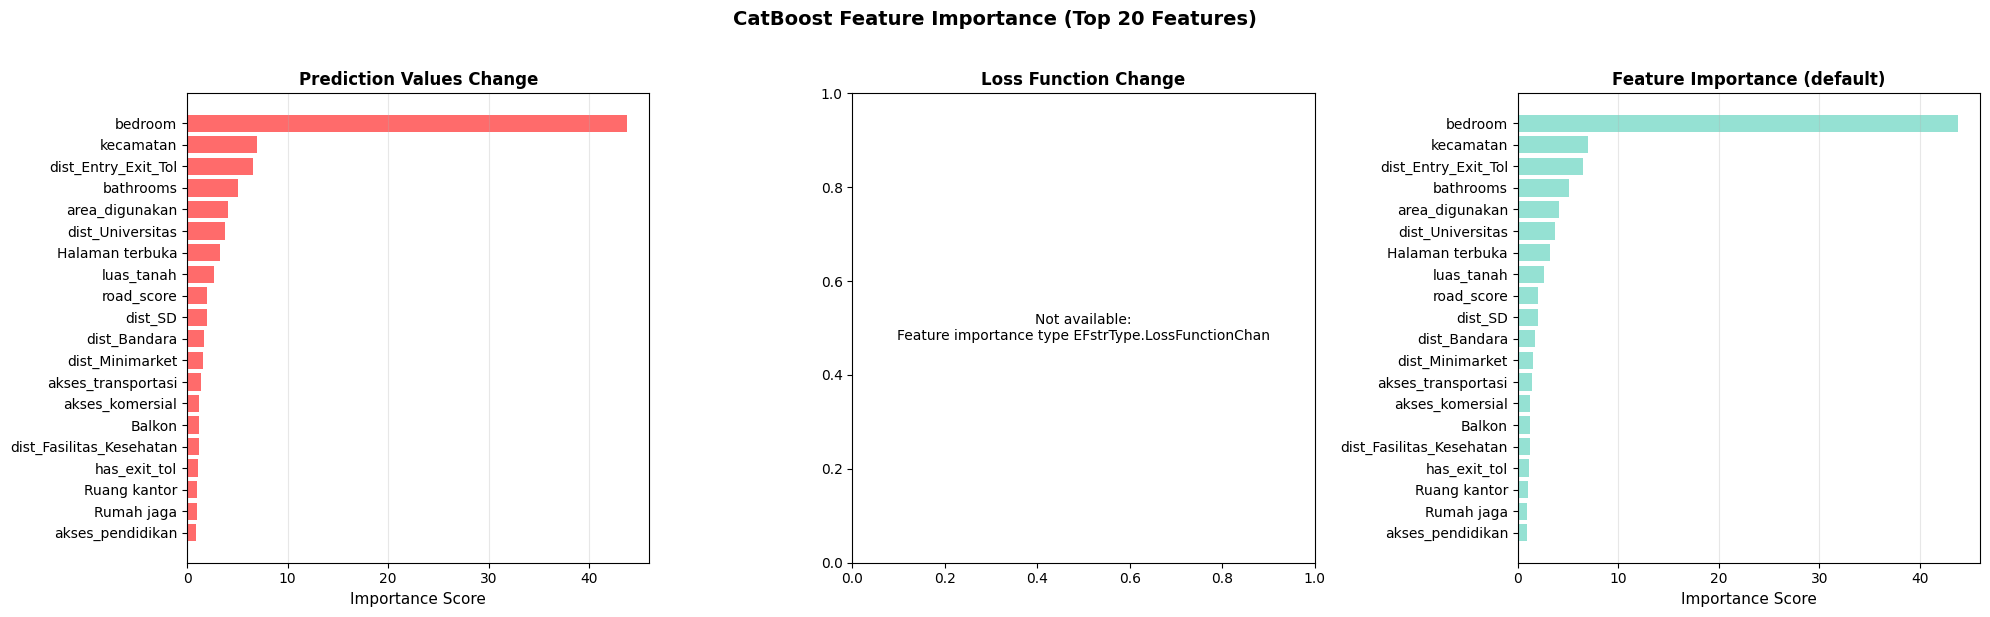


DETAILED FEATURE IMPORTANCE COMPARISON

Top 20 Most Important Features:
                 feature  importance_default  importance_pvc
                 bedroom           43.800996       43.800996
               kecamatan            6.987875        6.987875
     dist_Entry_Exit_Tol            6.517961        6.517961
               bathrooms            5.092656        5.092656
          area_digunakan            4.099407        4.099407
        dist_Universitas            3.730162        3.730162
         Halaman terbuka            3.225960        3.225960
              luas_tanah            2.655801        2.655801
              road_score            2.029471        2.029471
                 dist_SD            2.028803        2.028803
            dist_Bandara            1.690662        1.690662
         dist_Minimarket            1.546802        1.546802
      akses_transportasi            1.409252        1.409252
         akses_komersial            1.204183        1.204183
            

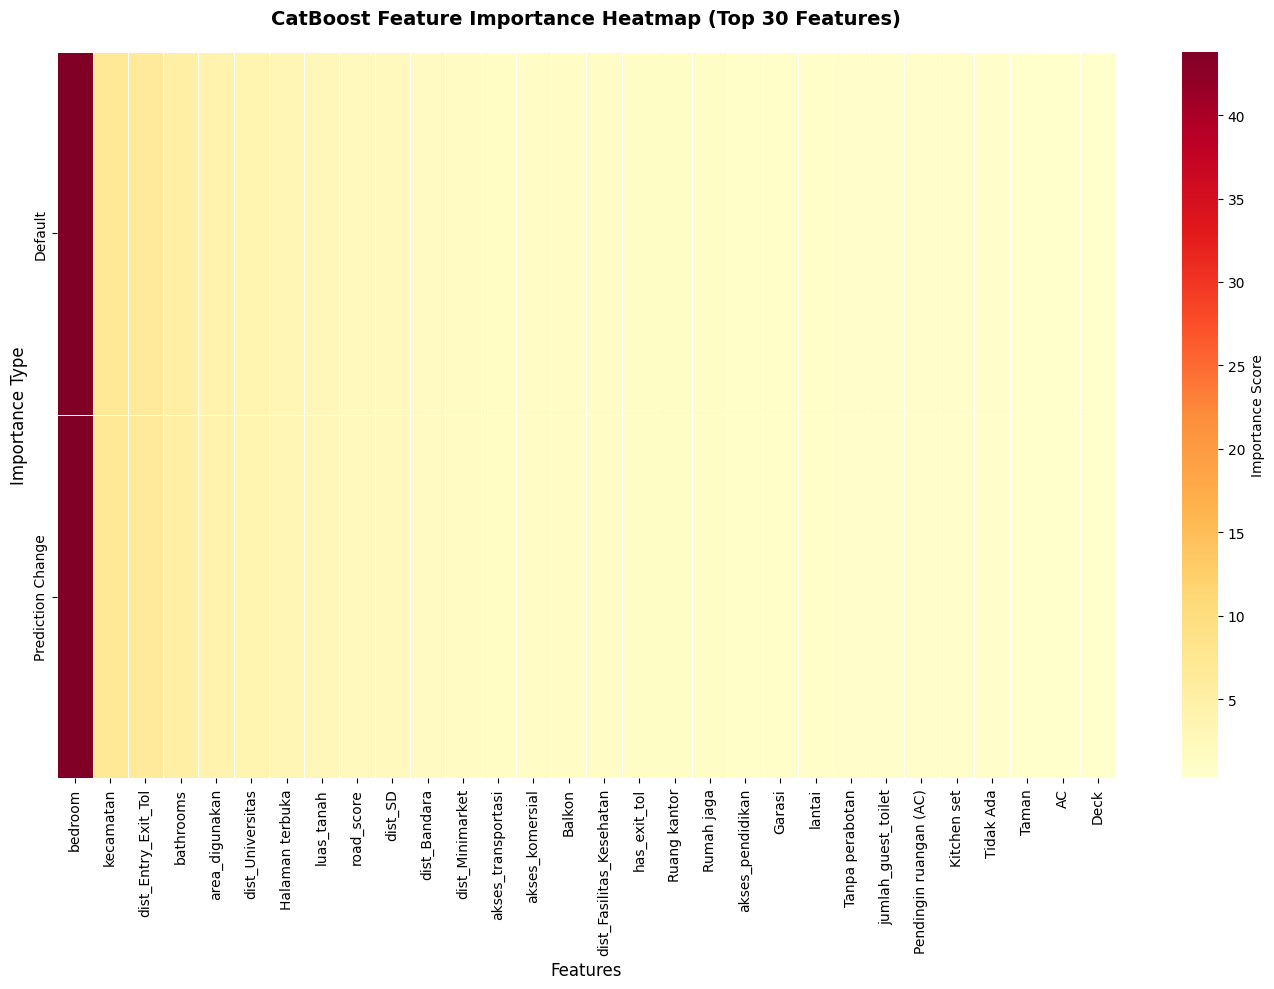

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CATBOOST FEATURE IMPORTANCE
# ============================================================================

# Method 1: Menggunakan get_feature_importance() - Native CatBoost
print("="*80)
print("CATBOOST FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Dapatkan feature importance dengan berbagai tipe
importance_types = {
    'PredictionValuesChange': 'Prediction Values Change',
    'LossFunctionChange': 'Loss Function Change', 
    'FeatureImportance': 'Feature Importance (default)'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (imp_type, title) in enumerate(importance_types.items()):
    try:
        # Get importance scores
        importance_scores = best_model.get_feature_importance(
            type=imp_type,
            prettified=False
        )
        
        # Create DataFrame
        importance_df = pd.DataFrame({
            'feature': X_train_CB.columns,
            'importance': importance_scores
        }).sort_values('importance', ascending=True).tail(20)
        
        # Plot
        axes[idx].barh(range(len(importance_df)), importance_df['importance'], color=['#FF6B6B', '#4ECDC4', '#95E1D3'][idx])
        axes[idx].set_yticks(range(len(importance_df)))
        axes[idx].set_yticklabels(importance_df['feature'])
        axes[idx].set_xlabel('Importance Score', fontsize=11)
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Not available:\n{str(e)[:50]}', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('CatBoost Feature Importance (Top 20 Features)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Method 2: Detailed DataFrame Analysis
print("\n" + "="*80)
print("DETAILED FEATURE IMPORTANCE COMPARISON")
print("="*80)

importance_comparison = pd.DataFrame({
    'feature': X_train_CB.columns,
    'importance_default': best_model.get_feature_importance(prettified=False)
})

# Tambahkan tipe lain jika tersedia
try:
    importance_comparison['importance_pvc'] = best_model.get_feature_importance(
        type='PredictionValuesChange', prettified=False
    )
except:
    pass

try:
    importance_comparison['importance_lfc'] = best_model.get_feature_importance(
        type='LossFunctionChange', prettified=False
    )
except:
    pass

# Sort by default importance
importance_comparison = importance_comparison.sort_values('importance_default', ascending=False)

print("\nTop 20 Most Important Features:")
print(importance_comparison.head(20).to_string(index=False))

# Method 3: Heatmap untuk perbandingan
plt.figure(figsize=(14, 10))

# Ambil top 30 features
top_30 = importance_comparison.head(30).copy()

# Pilih kolom numerik saja
numeric_cols = [col for col in top_30.columns if col.startswith('importance_')]
heatmap_data = top_30[numeric_cols].T

# Rename untuk label lebih baik
rename_map = {
    'importance_default': 'Default',
    'importance_pvc': 'Prediction Change',
    'importance_lfc': 'Loss Change'
}
heatmap_data.index = [rename_map.get(idx, idx) for idx in heatmap_data.index]

sns.heatmap(
    heatmap_data,
    xticklabels=top_30['feature'].values,
    yticklabels=heatmap_data.index,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'Importance Score'},
    linewidths=0.5
)

plt.title('CatBoost Feature Importance Heatmap (Top 30 Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Type', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### SHAP

In [25]:
# SHAP Analysis untuk CatBoost
# CatBoost memiliki native support yang lebih baik untuk SHAP!

import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SHAP ANALYSIS - CATBOOST MODEL")
print("="*80)

# Step 1: Ambil sample data untuk efisiensi komputasi
print("\n[1/4] Preparing data for SHAP analysis...")

n_samples = min(1000, len(X_train_CB))
sample_indices = X_train_CB.sample(n_samples, random_state=42).index
X_shap_sample = X_train_CB.loc[sample_indices].copy()
y_shap_sample = y_train_CB.loc[sample_indices].copy()

# Simpan nama kolom
feature_names_cb = X_shap_sample.columns.tolist()

print(f"   Sample size: {X_shap_sample.shape}")
print(f"   Features: {len(feature_names_cb)}")

# Step 2: Create SHAP explainer - SANGAT MUDAH dengan CatBoost!
print("\n[2/4] Creating SHAP TreeExplainer for CatBoost...")
shap_success = False
shap_values_cb = None
explainer_cb = None
expected_value_cb = None

try:
    # CatBoost native support - langsung gunakan model yang sudah di-train!
    explainer_cb = shap.TreeExplainer(best_model)
    expected_value_cb = explainer_cb.expected_value
    print("   ✓ TreeExplainer created successfully")
    print(f"   ✓ Base value: Rp {float(expected_value_cb):,.0f}")
    shap_success = True
except Exception as e:
    print(f"   ✗ TreeExplainer failed: {str(e)}")
    shap_success = False

# Step 3: Calculate SHAP values
if shap_success and explainer_cb is not None:
    print("\n[3/4] Calculating SHAP values...")
    try:
        shap_values_cb = explainer_cb.shap_values(X_shap_sample)
        
        print(f"   ✓ SHAP values calculated!")
        print(f"   Shape: {shap_values_cb.shape}")
        
        # Step 4: Verify with predictions
        print("\n[4/4] Verifying model performance on sample...")
        train_pred_cb = best_model.predict(X_shap_sample)
        train_rmse = np.sqrt(mean_squared_error(y_shap_sample, train_pred_cb))
        train_mae = mean_absolute_error(y_shap_sample, train_pred_cb)
        print(f"   RMSE: Rp {train_rmse:,.0f}")
        print(f"   MAE: Rp {train_mae:,.0f}")
        
        print("\n" + "="*80)
        print("✓ CATBOOST SHAP ANALYSIS COMPLETED SUCCESSFULLY!")
        print("="*80)
        
    except Exception as e:
        print(f"\n   ✗ Failed to calculate SHAP values: {e}")
        shap_success = False
        shap_values_cb = None
else:
    print("\n" + "="*80)
    print("✗ SHAP ANALYSIS FAILED")
    print("="*80)
    shap_values_cb = None
    train_pred_cb = None

SHAP ANALYSIS - CATBOOST MODEL

[1/4] Preparing data for SHAP analysis...
   Sample size: (978, 72)
   Features: 72

[2/4] Creating SHAP TreeExplainer for CatBoost...
   ✓ TreeExplainer created successfully
   ✓ Base value: Rp -9,877,957

[3/4] Calculating SHAP values...
   ✓ SHAP values calculated!
   Shape: (978, 72)

[4/4] Verifying model performance on sample...
   RMSE: Rp 930,798,152
   MAE: Rp 343,248,289

✓ CATBOOST SHAP ANALYSIS COMPLETED SUCCESSFULLY!


In [26]:
# Summary Statistics SHAP Values - CatBoost
if shap_values_cb is not None:
    print("="*80)
    print("CATBOOST SHAP ANALYSIS SUMMARY")
    print("="*80)

    shap_summary_cb = pd.DataFrame({
        'Feature': feature_names_cb,
        'Mean_|SHAP|': np.abs(shap_values_cb).mean(axis=0),
        'Std_SHAP': np.abs(shap_values_cb).std(axis=0),
        'Max_|SHAP|': np.abs(shap_values_cb).max(axis=0),
        'Mean_SHAP': shap_values_cb.mean(axis=0)
    }).sort_values('Mean_|SHAP|', ascending=False)

    print("\nTop 20 Features by Mean Absolute SHAP Value:")
    print(shap_summary_cb.head(20).to_string(index=False))

    print("\n" + "="*80)
    print(f"Model Base Value (Expected): Rp {float(expected_value_cb):,.0f}")
    print(f"Mean Prediction: Rp {train_pred_cb.mean():,.0f}")
    print(f"Actual Mean Price: Rp {y_shap_sample.mean():,.0f}")
    print("="*80)
else:
    print("⚠ SHAP values not available. Skipping summary.")

CATBOOST SHAP ANALYSIS SUMMARY

Top 20 Features by Mean Absolute SHAP Value:
            Feature  Mean_|SHAP|     Std_SHAP   Max_|SHAP|     Mean_SHAP
            bedroom 2.003440e+08 4.096213e+08 7.831563e+09 -1.214192e+07
          kecamatan 1.000754e+08 9.378769e+07 1.150607e+09  2.118204e+07
          bathrooms 9.321393e+07 1.090135e+08 1.128403e+09  7.569957e+06
     area_digunakan 4.790008e+07 2.849756e+07 5.183286e+08 -6.412001e+06
dist_Entry_Exit_Tol 4.267537e+07 7.187141e+07 1.203679e+09 -2.743838e+06
   dist_Universitas 3.877140e+07 5.088245e+07 1.120808e+09  6.438569e+06
         luas_tanah 3.016195e+07 2.457927e+07 4.476234e+08 -3.089700e+06
    dist_Minimarket 2.402107e+07 2.053386e+07 2.744156e+08  3.114845e+06
             Balkon 2.021462e+07 2.858407e+07 1.924978e+08 -1.732366e+06
             lantai 1.623684e+07 2.093429e+07 4.691366e+08  2.884870e+06
    akses_komersial 1.579059e+07 1.071939e+07 1.601418e+08  1.552805e+06
         road_score 1.428593e+07 3.432208e+07 9

In [28]:
# Export SHAP values untuk analisis lebih lanjut - CatBoost
if shap_values_cb is not None:
    shap_df_cb = pd.DataFrame(
        shap_values_cb,
        columns=[f'shap_{col}' for col in feature_names_cb]
    )

    # Gabung dengan data asli
    shap_analysis_df_cb = pd.concat([
        X_shap_sample.reset_index(drop=True),
        shap_df_cb.reset_index(drop=True),
        pd.Series(y_shap_sample.values, name='actual_price')
    ], axis=1)

    # Tambahkan prediksi
    shap_analysis_df_cb['predicted_price'] = train_pred_cb
    shap_analysis_df_cb['prediction_error'] = shap_analysis_df_cb['actual_price'] - shap_analysis_df_cb['predicted_price']

    print("CatBoost SHAP Analysis DataFrame:")
    print(shap_analysis_df_cb.head())
    print(f"\nShape: {shap_analysis_df_cb.shape}")

CatBoost SHAP Analysis DataFrame:
  kecamatan  bedroom  bathrooms  jumlah_guest_toilet  lantai  area_digunakan  \
0   Buduran        2          1                    1       1              36   
1     Taman        3          2                    0       2              90   
2     Taman        3          2                    2       1              50   
3  Sukodono        2          1                    0       1             150   
4    Sedati        2          1                    1       1             100   

   luas_tanah   dist_SD  dist_Universitas  dist_Fasilitas_Kesehatan  ...  \
0          72  3.909136          7.258131                  5.708731  ...   
1          90  2.631206          6.911361                  5.760949  ...   
2         112  1.342664          4.772823                  1.479492  ...   
3         135  2.579776          4.922090                  2.978413  ...   
4         128  1.045183          3.275766                  6.202500  ...   

   shap_Taman atap  shap_Tam

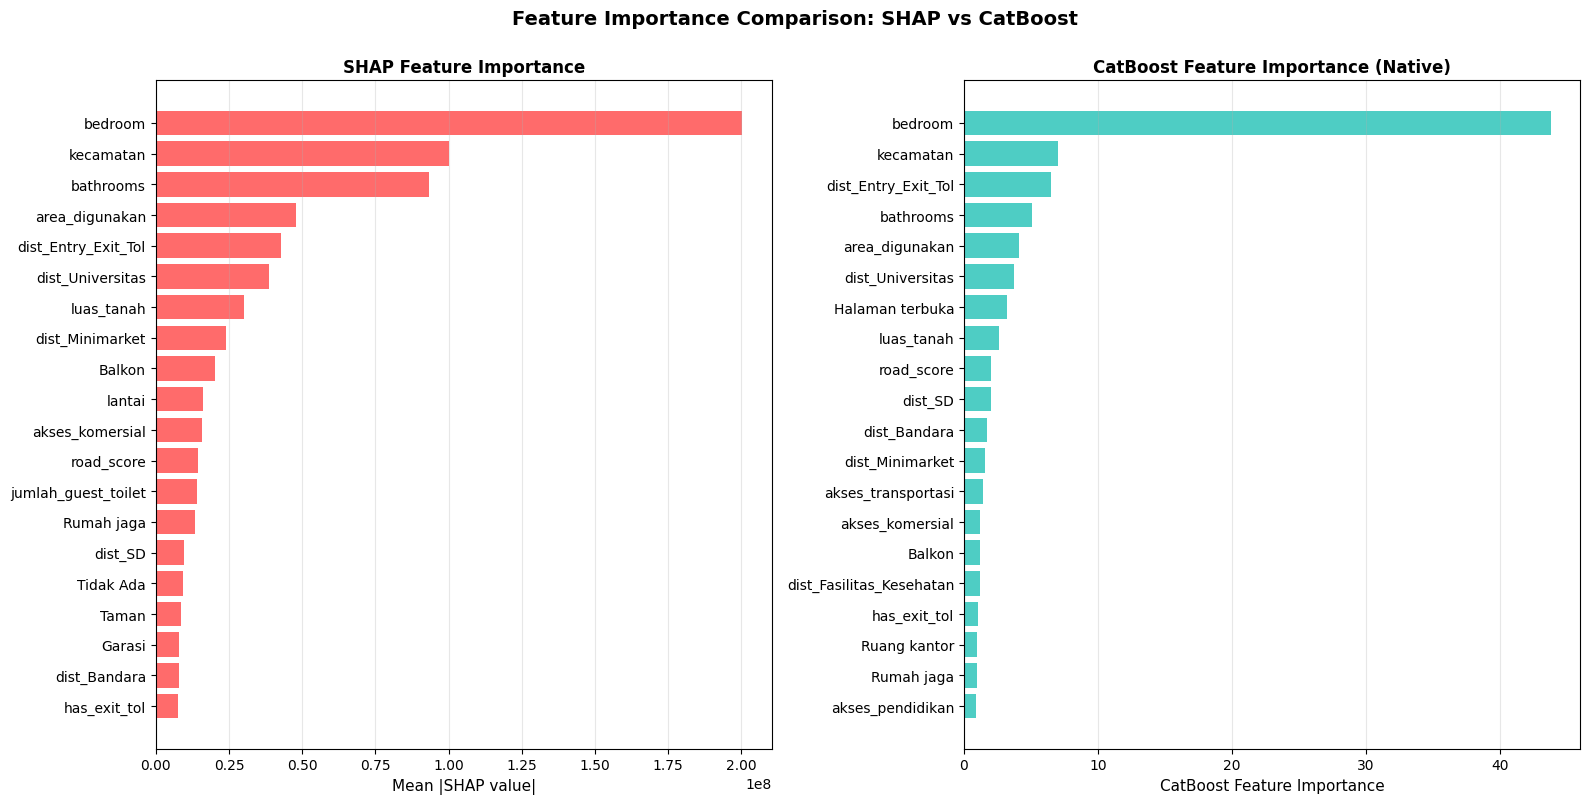

In [32]:
# SHAP Feature Importance Comparison dengan CatBoost Feature Importance
if shap_values_cb is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # SHAP Importance
    shap_importance_cb = pd.DataFrame({
        'feature': feature_names_cb,
        'shap_importance': np.abs(shap_values_cb).mean(axis=0)
    }).sort_values('shap_importance', ascending=True).tail(20)

    axes[0].barh(range(len(shap_importance_cb)), shap_importance_cb['shap_importance'], color='#FF6B6B')
    axes[0].set_yticks(range(len(shap_importance_cb)))
    axes[0].set_yticklabels(shap_importance_cb['feature'])
    axes[0].set_xlabel('Mean |SHAP value|', fontsize=11)
    axes[0].set_title('SHAP Feature Importance', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # CatBoost Importance (Native)
    cb_importance = pd.DataFrame({
        'feature': X_train_CB.columns,
        'cb_importance': best_model.get_feature_importance()
    }).sort_values('cb_importance', ascending=True).tail(20)

    axes[1].barh(range(len(cb_importance)), cb_importance['cb_importance'], color='#4ECDC4')
    axes[1].set_yticks(range(len(cb_importance)))
    axes[1].set_yticklabels(cb_importance['feature'])
    axes[1].set_xlabel('CatBoost Feature Importance', fontsize=11)
    axes[1].set_title('CatBoost Feature Importance (Native)', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    plt.suptitle('Feature Importance Comparison: SHAP vs CatBoost', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping comparison plot.")

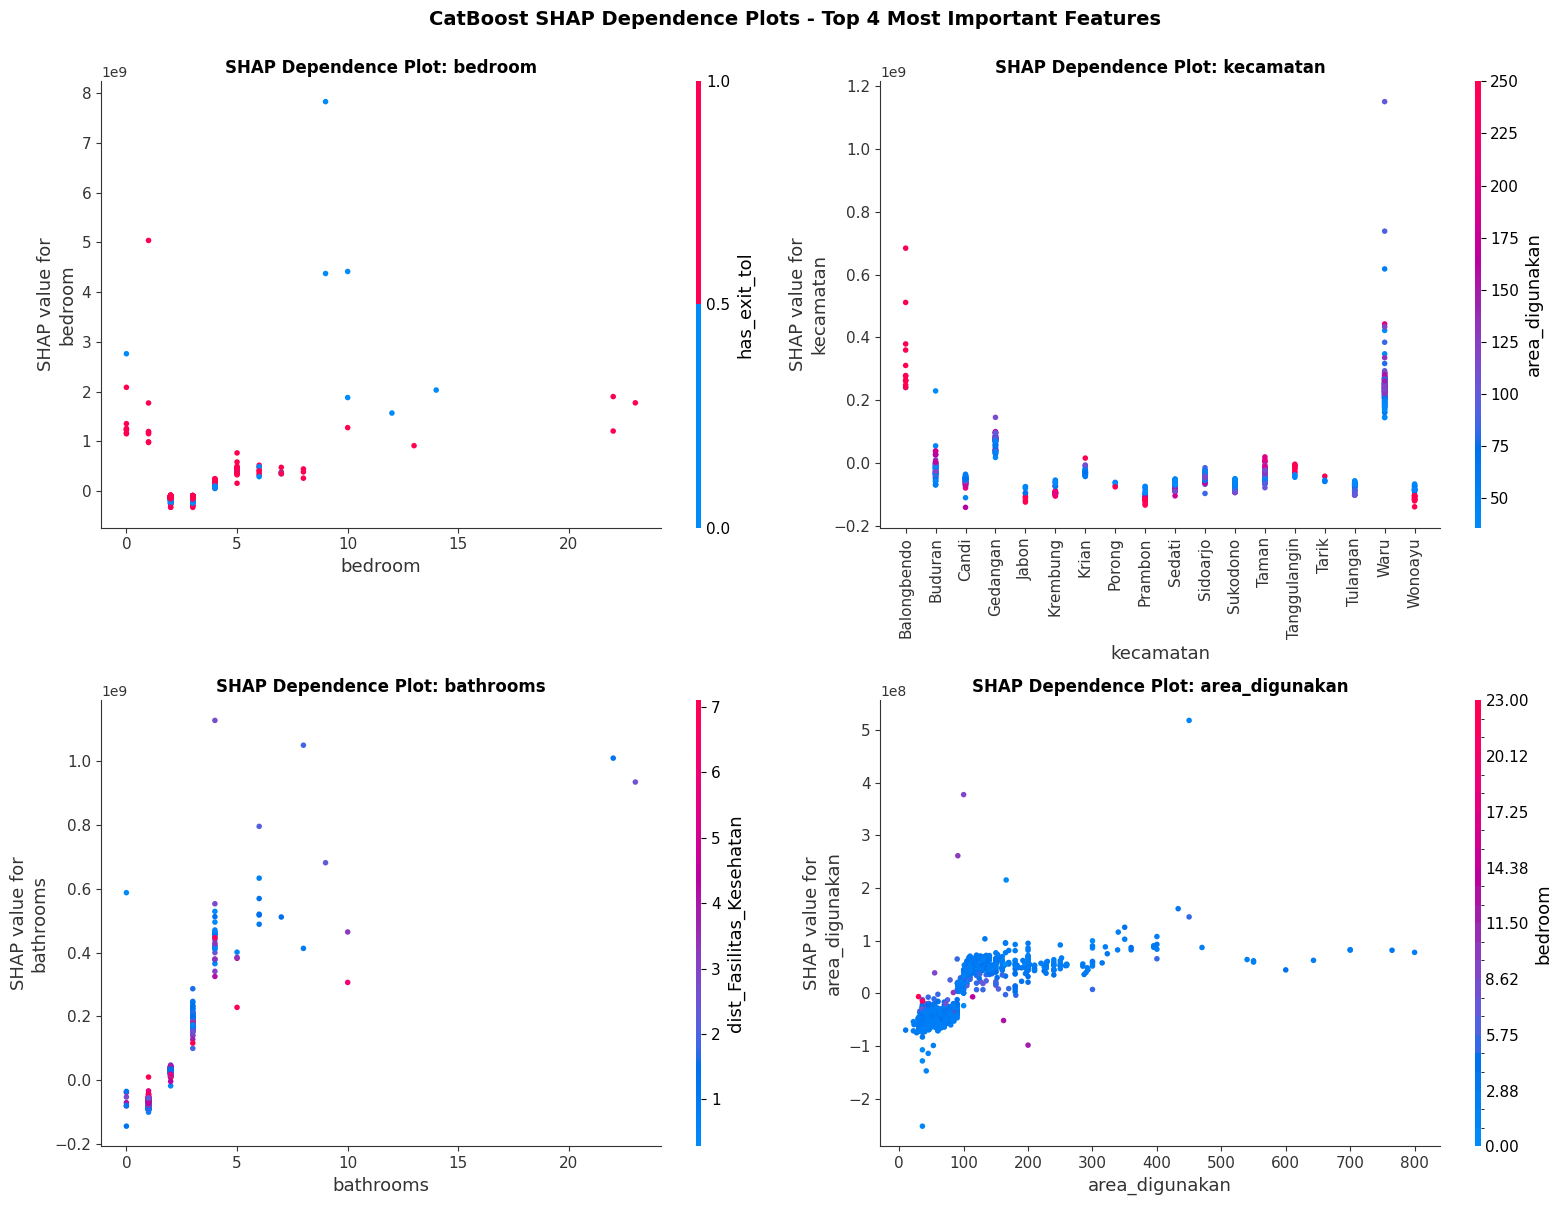

In [34]:
# SHAP Dependence Plot - Top 4 features - CatBoost
if shap_values_cb is not None:
    # Get top 4 features by mean absolute SHAP
    shap_importance_cb = pd.DataFrame({
        'feature': feature_names_cb,
        'importance': np.abs(shap_values_cb).mean(axis=0)
    }).sort_values('importance', ascending=False)

    top_4_features_cb = shap_importance_cb.head(4)['feature'].tolist()
    top_4_indices_cb = [feature_names_cb.index(f) for f in top_4_features_cb]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, (feature, feat_idx) in enumerate(zip(top_4_features_cb, top_4_indices_cb)):
        plt.sca(axes[i])
        shap.dependence_plot(
            feat_idx,
            shap_values_cb,
            X_shap_sample,
            feature_names=feature_names_cb,
            interaction_index="auto",
            show=False,
            ax=axes[i]
        )
        axes[i].set_title(f'SHAP Dependence Plot: {feature}', fontsize=12, fontweight='bold')

    plt.suptitle('CatBoost SHAP Dependence Plots - Top 4 Most Important Features', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping dependence plots.")

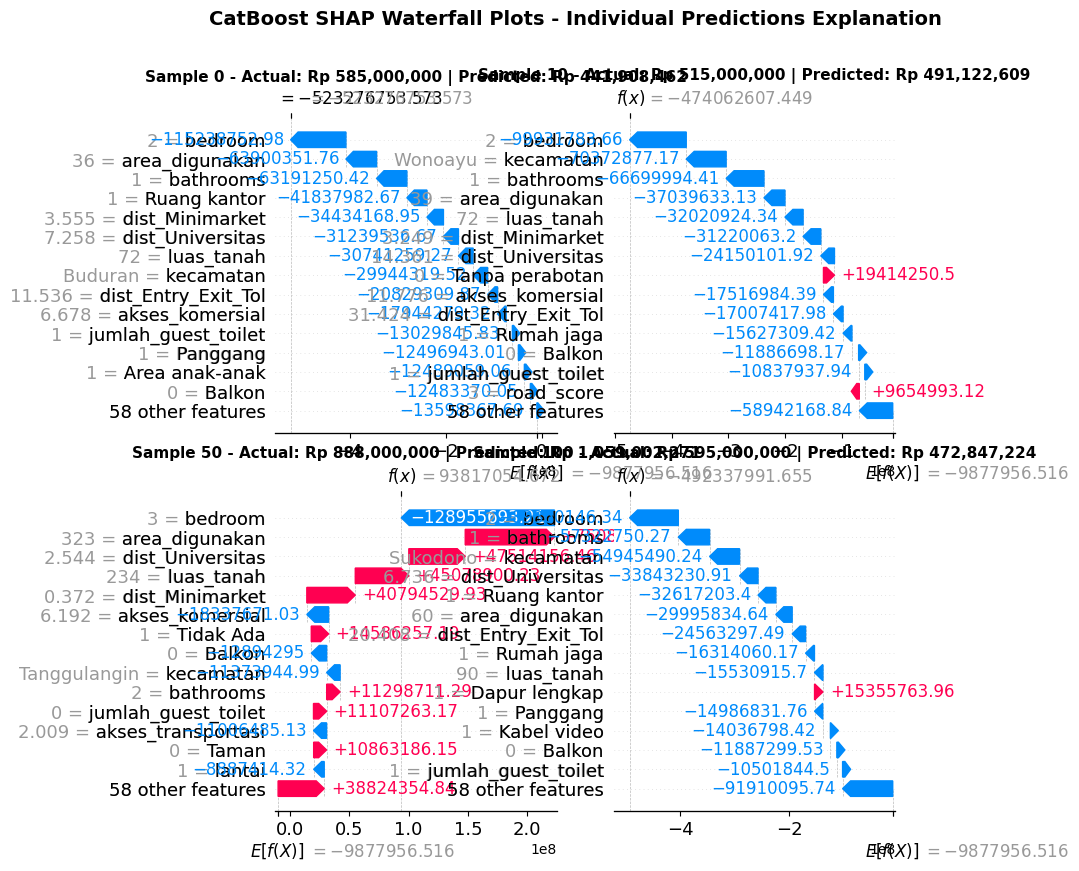

In [35]:
# SHAP Waterfall Plot - Contoh prediksi individual - CatBoost
if shap_values_cb is not None and expected_value_cb is not None:
    sample_idx = [0, 10, 50, 100]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, idx in enumerate(sample_idx):
        if idx < len(X_shap_sample):
            plt.sca(axes[i])
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values_cb[idx],
                    base_values=float(expected_value_cb),
                    data=X_shap_sample.iloc[idx].values,
                    feature_names=feature_names_cb
                ),
                max_display=15,
                show=False
            )
            
            actual_price = y_shap_sample.iloc[idx]
            predicted_price = train_pred_cb[idx]
            axes[i].set_title(f'Sample {idx} - Actual: Rp {actual_price:,.0f} | Predicted: Rp {predicted_price:,.0f}', 
                             fontsize=11, fontweight='bold')

    plt.suptitle('CatBoost SHAP Waterfall Plots - Individual Predictions Explanation', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping waterfall plots.")

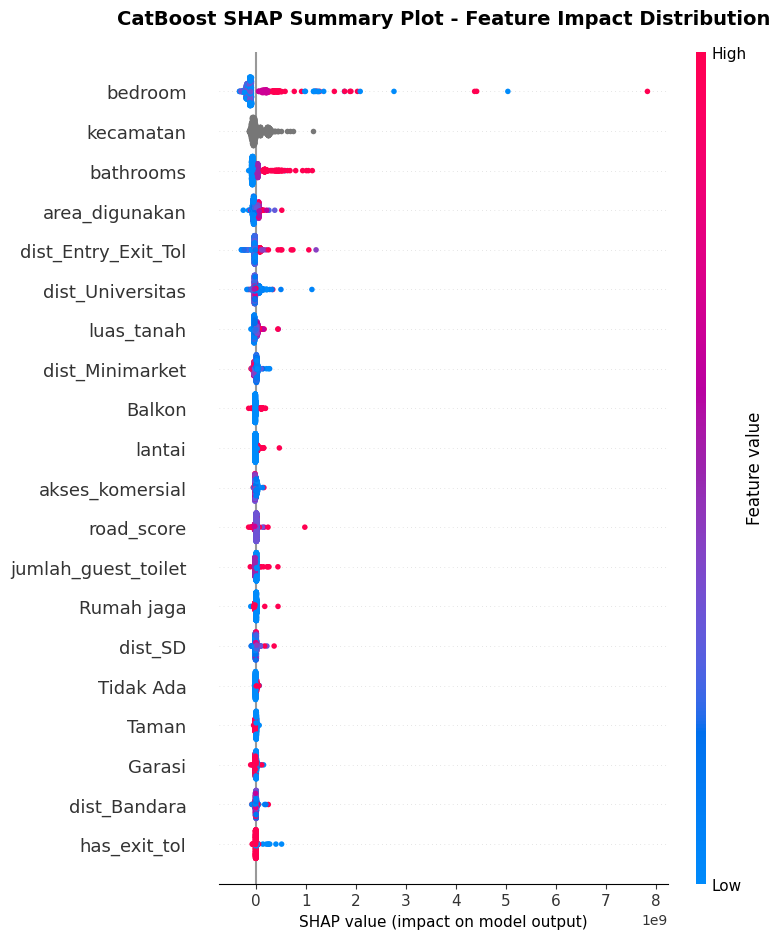

In [36]:
# SHAP Summary Plot - Beeswarm (Feature Impact Distribution) - CatBoost
if shap_values_cb is not None:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_cb, X_shap_sample, feature_names=feature_names_cb, max_display=20, show=False)
    plt.title('CatBoost SHAP Summary Plot - Feature Impact Distribution', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('SHAP value (impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping beeswarm plot.")

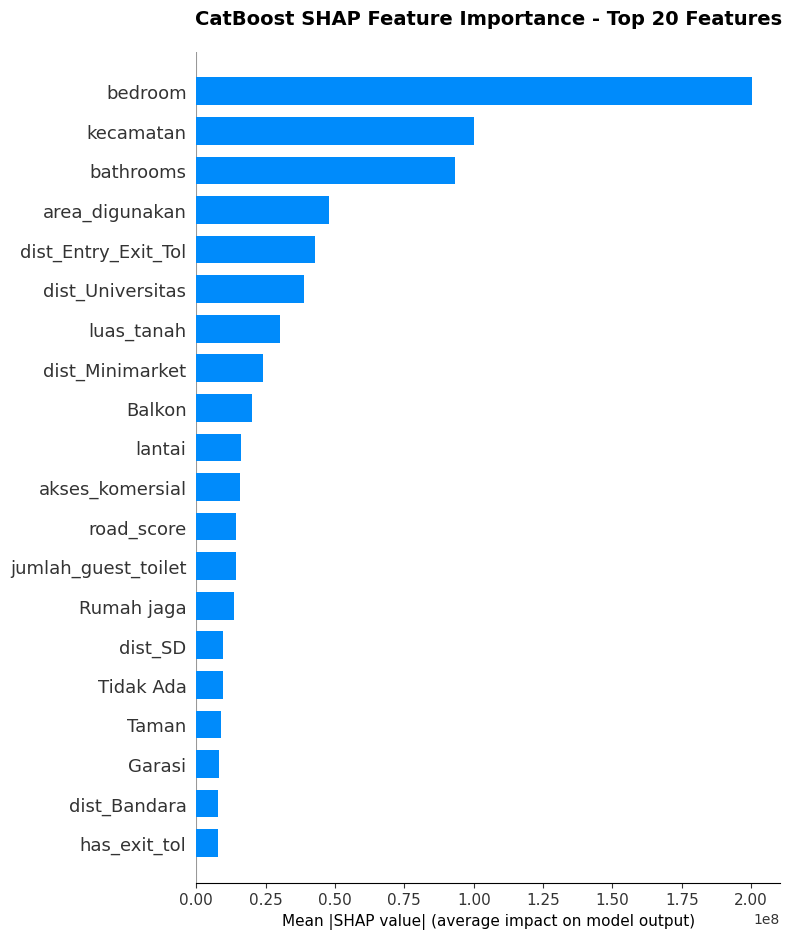

In [ ]:
# SHAP Summary Plot - Bar (Feature Importance) - CatBoost
if shap_values_cb is not None:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_cb, X_shap_sample, feature_names=feature_names_cb, plot_type="bar", max_display=20, show=False)
    plt.title('CatBoost SHAP Feature Importance - Top 20 Features', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Mean |SHAP value| (average impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping bar plot.")